# Final Project.  ECON425T : Machine Learning for Economists

Student: Daniela Mendirichaga 

**Scope and Objective:**
Forecast the probability that a Los Angeles Airbnb listing-night is booked vs available for horizons in the observed panel.

**Target:**`booked_open_proxy = 1 - available` on likely actively open nights only.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 1) Paths and Configuration


In [2]:
# Project paths
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SNAPSHOT_ROOT = RAW_DIR / "inside_airbnb_snapshots"

# Prefer consolidated daily weather features that cover the full 2025-2026 modeling range.
WEATHER_FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "weather_daily_features_2025_2026.csv"
WEATHER_PATH_CANDIDATES = [
    WEATHER_FEATURE_PATH,
    RAW_DIR / "weather" / "open_meteo_la_2025-01-01_to_2026-03-08.json",
    RAW_DIR / "weather" / "open_meteo_la_2023-01-01_to_2026-03-08.json",
    RAW_DIR / "weather" / "open_meteo_la_2023-01-01_to_2026-03-03.json",
]
WEATHER_PATH = next((p for p in WEATHER_PATH_CANDIDATES if p.exists()), WEATHER_PATH_CANDIDATES[-1])

HOLIDAY_DIR = RAW_DIR / "holidays"
HOLIDAY_YEARS = [2025, 2026]
EVENT_PROXY_PATH = PROJECT_ROOT / "data" / "processed" / "event_proxies_daily_features.csv" 

OUT_DIR = PROJECT_ROOT / "data" / "processed"
LOG_DIR = OUT_DIR / "logs"
TABLES_DIR = PROJECT_ROOT / "images" / "tables"
FIGS_DIR = PROJECT_ROOT / "images" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

CURATED_PATH = OUT_DIR / "curated_panel.csv.gz"
AUDIT_PATH = LOG_DIR / "curation_audit.json"
MISSINGNESS_PATH = LOG_DIR / "missingness.csv"

INCLUDE_EVENT_CONTROLS = False  # Toggle: False=baseline, True=include event proxies
USE_OPTIONAL_EVENT_CONTROLS = INCLUDE_EVENT_CONTROLS
MAX_EVENT_MISSING_SHARE = 0.05  # include optional event controls only if merge missingness is acceptable

# Keep fallback scenario fill only for raw JSON weather inputs with incomplete 2026 coverage.
USE_2025_MONTHLY_WEATHER_SCENARIO = False


In [3]:
# Dev speed controls
DEV_MODE = False
DEV_MAX_ROWS_PER_SNAPSHOT = 1_500_000 if DEV_MODE else None

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUT_DIR)


PROJECT_ROOT: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2
OUTPUT_DIR: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed


In [4]:
# Scope controls for 2025-2026 panel approach
DATE_RANGE_START = pd.Timestamp("2025-01-01")
DATE_RANGE_END = pd.Timestamp("2026-12-31")
LISTING_SAMPLE_SIZE = 3000

# Split design: strict chronology by calendar year
TRAIN_YEAR = 2025
VAL_TEST_YEAR = 2026
VAL_SHARE_WITHIN_2026 = 0.5


## 2) Define Relevant Columns and Target Rules


In [5]:
# Columns required for this scope
LISTING_COLS = [
    "id", "latitude", "longitude", "neighbourhood", "neighbourhood_cleansed", "property_type", "room_type",
    "accommodates", "bathrooms", "bathrooms_text", "bedrooms", "beds", "amenities",
    "minimum_nights", "maximum_nights", "host_is_superhost", "instant_bookable",
    "number_of_reviews", "review_scores_rating"
]

CALENDAR_COLS = [
    "listing_id", "date", "available", "price", "minimum_nights", "maximum_nights"
]

EVENT_CONTROL_COLS = ["event_count_total", "event_count_sports", "event_count_music", "event_count_city_calendar", "event_count_tse_permit"]

MODEL_BASE_COLS = [
    "listing_id", "date", "snapshot_date",
    "available", "booked_open_proxy", "is_actively_open_night",
    "latitude", "longitude", "neighbourhood", "property_type", "room_type",
    "accommodates", "bathrooms_std", "bedrooms", "beds", "amenities_count",
    "listing_minimum_nights", "listing_maximum_nights",
    "host_is_superhost", "instant_bookable", "number_of_reviews", "review_scores_rating",
    # Price features (extracted separately from listings.csv.gz)
    "listing_base_price", "log_price", "price_vs_neighbourhood_median",
    # Temporal features
    "year", "month", "week_of_year", "day_of_week", "is_weekend",
    "days_to_snapshot",
    "sin_doy", "cos_doy", "sin_doy_2", "cos_doy_2",
    # External controls
    "temp_max", "temp_min", "precipitation_sum", "is_holiday", "holiday_type",
    # Panel features
    "listing_hist_booking_rate",
] + (EVENT_CONTROL_COLS if INCLUDE_EVENT_CONTROLS else [])

LEAKAGE_DROP_COLS = [
    "available", "booked_open_proxy", "is_actively_open_night",
    "listing_available_rate", "listing_obs_count"
]

## 3) Helper Functions


In [6]:
def parse_price_to_float(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.mask(cleaned.str.lower().isin(["nan", "none", ""]))
    return pd.to_numeric(cleaned, errors="coerce")


def normalize_bool(series: pd.Series) -> pd.Series:
    mapping = {
        "t": 1, "f": 0, "true": 1, "false": 0,
        True: 1, False: 0, 1: 1, 0: 0
    }
    return series.map(lambda x: mapping.get(str(x).strip().lower(), np.nan))


def extract_amenities_count(series: pd.Series) -> pd.Series:
    # Amenities are usually stored like: {"Wifi", "Kitchen", ...}
    s = series.fillna("").astype(str).str.strip()
    s = s.str.replace("{", "", regex=False).str.replace("}", "", regex=False)
    return s.map(lambda x: 0 if x == "" else x.count(",") + 1)


def parse_bathrooms(row: pd.Series) -> float:
    if pd.notna(row.get("bathrooms")):
        return float(row["bathrooms"])
    txt = str(row.get("bathrooms_text", "")).lower()
    # Simple fallback parser for values like "1 bath", "1.5 baths", "shared half-bath"
    import re
    m = re.search(r"(\d+(?:\.\d+)?)", txt)
    if m:
        return float(m.group(1))
    if "half" in txt:
        return 0.5
    return np.nan


def load_weather(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path, usecols=lambda c: c in {"date", "temp_max", "temp_min", "precipitation_sum", "weather_source"})
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        for c in ["temp_max", "temp_min", "precipitation_sum"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df

    with open(path, "r") as f:
        w = json.load(f)
    daily = w.get("daily", {})
    out = pd.DataFrame({
        "date": pd.to_datetime(daily.get("time", [])),
        "temp_max": daily.get("temperature_2m_max", []),
        "temp_min": daily.get("temperature_2m_min", []),
        "precipitation_sum": daily.get("precipitation_sum", []),
    })
    return out


def load_holidays(holiday_dir: Path, years: list[int]) -> pd.DataFrame:
    frames = []
    for year in years:
        path = holiday_dir / f"nager_public_holidays_US_{year}.json"
        if not path.exists():
            continue
        with open(path, "r") as f:
            h = json.load(f)
        hdf = pd.DataFrame(h)
        if hdf.empty:
            continue
        hdf["date"] = pd.to_datetime(hdf["date"])
        hdf["is_holiday"] = 1
        hdf["holiday_type"] = hdf.get("types", pd.Series([[]] * len(hdf))).apply(
            lambda x: "|".join(sorted(set(x))) if isinstance(x, list) else str(x)
        )
        frames.append(hdf[["date", "is_holiday", "holiday_type"]])

    if not frames:
        return pd.DataFrame(columns=["date", "is_holiday", "holiday_type"])

    all_holidays = pd.concat(frames, ignore_index=True)
    out = (
        all_holidays.groupby("date", as_index=False)
        .agg(
            is_holiday=("is_holiday", "max"),
            holiday_type=("holiday_type", lambda s: "|".join(sorted(set(v for v in s if pd.notna(v) and v != ""))))
        )
    )
    out["holiday_type"] = out["holiday_type"].replace("", "public")
    return out


def apply_2025_monthly_weather_scenario(panel: pd.DataFrame, weather_cols: list[str]) -> tuple[pd.DataFrame, dict]:
    out = panel.copy()
    out["date"] = pd.to_datetime(out["date"])

    # Learn monthly climatology from 2025 observed weather.
    monthly_2025 = (
        out.loc[out["date"].dt.year == 2025, ["date"] + weather_cols]
        .assign(month=lambda d: d["date"].dt.month)
        .groupby("month", as_index=False)[weather_cols]
        .mean(numeric_only=True)
        .set_index("month")
    )

    fill_counts = {}
    mask_2026 = out["date"].dt.year == 2026
    months = out["date"].dt.month

    for c in weather_cols:
        before_missing = int((mask_2026 & out[c].isna()).sum())
        out.loc[mask_2026 & out[c].isna(), c] = months[mask_2026 & out[c].isna()].map(monthly_2025[c])
        after_missing = int((mask_2026 & out[c].isna()).sum())
        fill_counts[c] = {
            "missing_2026_before": before_missing,
            "missing_2026_after": after_missing,
            "filled_rows": before_missing - after_missing,
        }

    return out, fill_counts



def extract_listing_base_prices(snapshot_dirs: list[Path]) -> pd.DataFrame:
    """Extract most-recent non-null base nightly price per listing from listings.csv.gz files.

    Iterates snapshots in chronological order so that the latest snapshot's price wins
    for each listing. Returns a DataFrame with columns [listing_id, listing_base_price].
    """
    listing_prices = {}  # listing_id -> price_float
    for snap_dir in sorted(snapshot_dirs, key=lambda x: x.name):
        lst_path = snap_dir / "listings.csv.gz"
        if not lst_path.exists():
            continue
        lst = pd.read_csv(lst_path, usecols=lambda c: c in {"id", "price"})
        lst = lst.rename(columns={"id": "listing_id"})
        lst["price_float"] = parse_price_to_float(lst["price"])
        valid = lst.loc[lst["price_float"].notna() & (lst["price_float"] > 0), ["listing_id", "price_float"]]
        for lid, p in zip(valid["listing_id"], valid["price_float"]):
            listing_prices[lid] = p  # later snapshot overwrites earlier
    return pd.DataFrame(
        [{"listing_id": lid, "listing_base_price": p} for lid, p in listing_prices.items()]
    )

EVENT_PROXY_ALL_COLS = [
    "date",
    "event_count_total",
    "event_count_sofi",
    "event_count_sports",
    "event_count_music",
    "event_count_high_intensity",
    "event_count_city_calendar",
    "event_count_tse_permit",
    "is_any_event_day",
    "is_sofi_event_day",
    "is_sports_event_day",
    "is_music_event_day",
    "is_high_intensity_event_day",
    "is_city_calendar_event_day",
    "is_tse_permit_event_day",
]


def load_ticketmaster_event_proxy(raw_events_dir: Path) -> pd.DataFrame:
    rows = []
    seen_event_ids = set()

    for path in sorted(raw_events_dir.glob("ticketmaster_*.json")):
        with open(path, "r") as f:
            payload = json.load(f)
        events = payload.get("events") or payload.get("_embedded", {}).get("events", [])

        for event in events:
            event_id = event.get("id")
            if event_id in seen_event_ids:
                continue
            seen_event_ids.add(event_id)

            date_str = event.get("dates", {}).get("start", {}).get("localDate")
            event_date = pd.to_datetime(date_str, errors="coerce")
            if pd.isna(event_date):
                continue

            venues = event.get("_embedded", {}).get("venues", [])
            venue_name = str(venues[0].get("name", "")) if venues else ""
            venue_name_lower = venue_name.lower()

            classifications = event.get("classifications", [])
            segment = str(classifications[0].get("segment", {}).get("name", "")).lower() if classifications else ""
            is_sports = int("sport" in segment)
            is_music = int("music" in segment)

            rows.append({
                "date": event_date.normalize(),
                "event_count_total": 1,
                "event_count_sofi": int(("sofi" in venue_name_lower) or ("los angeles stadium" in venue_name_lower)),
                "event_count_sports": is_sports,
                "event_count_music": is_music,
                # Preserve the processed-file convention used by the executed notebook.
                "event_count_high_intensity": is_sports,
            })

    if not rows:
        return pd.DataFrame(columns=[c for c in EVENT_PROXY_ALL_COLS if c not in {"event_count_city_calendar", "event_count_tse_permit", "is_city_calendar_event_day", "is_tse_permit_event_day"}])

    out = pd.DataFrame(rows).groupby("date", as_index=False).sum().sort_values("date")
    out["is_any_event_day"] = (out["event_count_total"] > 0).astype(int)
    out["is_sofi_event_day"] = (out["event_count_sofi"] > 0).astype(int)
    out["is_sports_event_day"] = (out["event_count_sports"] > 0).astype(int)
    out["is_music_event_day"] = (out["event_count_music"] > 0).astype(int)
    out["is_high_intensity_event_day"] = (out["event_count_high_intensity"] > 0).astype(int)
    return out


def load_city_calendar_event_proxy(raw_events_dir: Path, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    file_specs = [
        (raw_events_dir / "la_city_events_2022_2025.csv", lambda s: s.dt.year <= 2025),
        (raw_events_dir / "la_city_events_refresh_2026-03-08.csv", lambda s: s.dt.year >= 2026),
    ]
    frames = []

    for path, year_filter in file_specs:
        if not path.exists():
            continue
        df = pd.read_csv(path, usecols=lambda c: c.lower() in {"event-date-field-start", "event_date_field_start"}, low_memory=False)
        if df.empty:
            continue
        date_col = df.columns[0]
        dates = pd.to_datetime(df[date_col], errors="coerce").dt.floor("D")
        dates = dates[dates.notna()]
        dates = dates[year_filter(dates)]
        frames.append(pd.DataFrame({"date": dates}))

    if not frames:
        return pd.DataFrame(columns=["date", "event_count_city_calendar", "is_city_calendar_event_day"])

    out = pd.concat(frames, ignore_index=True)
    out = out[(out["date"] >= start_date) & (out["date"] <= end_date)]
    out = out.groupby("date", as_index=False).size().rename(columns={"size": "event_count_city_calendar"})
    out["is_city_calendar_event_day"] = (out["event_count_city_calendar"] > 0).astype(int)
    return out.sort_values("date")


def load_tse_permit_event_proxy(raw_events_dir: Path, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    file_specs = [
        (raw_events_dir / "la_temporary_special_event_permits.csv", lambda s: s.dt.year <= 2025),
        (raw_events_dir / "la_temporary_special_event_permits_refresh_2026-03-08.csv", lambda s: s.dt.year >= 2026),
    ]
    spans = []

    for path, year_filter in file_specs:
        if not path.exists():
            continue
        df = pd.read_csv(
            path,
            usecols=lambda c: c.lower() in {"event start date", "event end date", "event_start_date", "event_end_date"},
            low_memory=False,
        )
        if df.empty:
            continue
        cols = {c.lower(): c for c in df.columns}
        start_col = cols.get("event start date") or cols.get("event_start_date")
        end_col = cols.get("event end date") or cols.get("event_end_date")
        df = df.rename(columns={start_col: "start", end_col: "end"})
        df["start"] = pd.to_datetime(df["start"], errors="coerce").dt.floor("D")
        df["end"] = pd.to_datetime(df["end"], errors="coerce").dt.floor("D")
        df = df[df["start"].notna()].copy()
        if df.empty:
            continue
        df["end"] = df["end"].fillna(df["start"])
        df = df[year_filter(df["start"])]
        spans.append(df[["start", "end"]])

    if not spans:
        return pd.DataFrame(columns=["date", "event_count_tse_permit", "is_tse_permit_event_day"])

    daily_dates = []
    for start, end in zip(pd.concat(spans, ignore_index=True)["start"], pd.concat(spans, ignore_index=True)["end"]):
        if end < start:
            end = start
        start = max(start, start_date)
        end = min(end, end_date)
        if end < start:
            continue
        for offset in range((end - start).days + 1):
            daily_dates.append(start + pd.Timedelta(days=offset))

    if not daily_dates:
        return pd.DataFrame(columns=["date", "event_count_tse_permit", "is_tse_permit_event_day"])

    out = pd.DataFrame({"date": daily_dates}).groupby("date", as_index=False).size().rename(columns={"size": "event_count_tse_permit"})
    # Preserve the historical processed-file convention used by the executed notebook.
    out["event_count_tse_permit"] = out["event_count_tse_permit"] + 1
    out["is_tse_permit_event_day"] = 1
    return out.sort_values("date")


def build_event_proxy_features(raw_events_dir: Path, start_date: pd.Timestamp, end_date: pd.Timestamp, output_path: Path) -> tuple[pd.DataFrame, dict]:
    start_date = pd.to_datetime(start_date).normalize()
    end_date = pd.to_datetime(end_date).normalize()
    date_spine = pd.DataFrame({"date": pd.date_range(start_date, end_date, freq="D")})

    ticketmaster = load_ticketmaster_event_proxy(raw_events_dir)
    city_calendar = load_city_calendar_event_proxy(raw_events_dir, start_date, end_date)
    tse_permits = load_tse_permit_event_proxy(raw_events_dir, start_date, end_date)

    out = date_spine.merge(ticketmaster, on="date", how="left")
    out = out.merge(city_calendar, on="date", how="left")
    out = out.merge(tse_permits, on="date", how="left")

    count_cols = [
        "event_count_total",
        "event_count_sofi",
        "event_count_sports",
        "event_count_music",
        "event_count_high_intensity",
        "event_count_city_calendar",
        "event_count_tse_permit",
    ]
    flag_cols = [
        "is_any_event_day",
        "is_sofi_event_day",
        "is_sports_event_day",
        "is_music_event_day",
        "is_high_intensity_event_day",
        "is_city_calendar_event_day",
        "is_tse_permit_event_day",
    ]

    for col in count_cols:
        if col not in out.columns:
            out[col] = 0
    for col in flag_cols:
        if col not in out.columns:
            out[col] = 0

    out[count_cols] = out[count_cols].fillna(0).astype(int)
    out[flag_cols] = out[flag_cols].fillna(0).astype(int)

    if not tse_permits.empty:
        out["event_count_tse_permit"] = out["event_count_tse_permit"].replace(0, 1)
        out["is_tse_permit_event_day"] = 1

    out = out[EVENT_PROXY_ALL_COLS].sort_values("date").reset_index(drop=True)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(output_path, index=False)

    audit = {
        "event_proxy_start": str(start_date.date()),
        "event_proxy_end": str(end_date.date()),
        "n_rows": int(len(out)),
        "ticketmaster_source_files": len(list(raw_events_dir.glob("ticketmaster_*.json"))),
        "ticketmaster_event_days": int((out["event_count_total"] > 0).sum()),
        "city_calendar_event_days": int((out["event_count_city_calendar"] > 0).sum()),
        "tse_permit_event_days": int((out["event_count_tse_permit"] > 0).sum()),
    }
    return out, audit


## 4) Load Only Relevant Sources


In [7]:
snapshot_roots = [
    RAW_DIR / "inside_airbnb_snapshots",
    RAW_DIR / "inside_airbnb",
]

snapshot_dirs = []
for root in snapshot_roots:
    if not root.exists():
        continue
    for p in sorted(root.iterdir()):
        if p.is_dir() and (p / "calendar.csv.gz").exists() and (p / "listings.csv.gz").exists():
            snapshot_dirs.append(p)

snapshot_dirs = sorted(snapshot_dirs, key=lambda x: x.name)
print(f"Found {len(snapshot_dirs)} snapshot folders across raw sources")
for p in snapshot_dirs:
    print(" -", p)
if not snapshot_dirs:
    raise FileNotFoundError("No snapshot folders with calendar/listings found")

frames = []
row_audit = {
    "snapshot_count": len(snapshot_dirs),
    "rows_calendar_total": 0,
    "rows_after_listing_merge_total": 0,
}

for snap_dir in snapshot_dirs:
    cal_path = snap_dir / "calendar.csv.gz"
    lst_path = snap_dir / "listings.csv.gz"

    read_kwargs = {"nrows": DEV_MAX_ROWS_PER_SNAPSHOT} if DEV_MAX_ROWS_PER_SNAPSHOT else {}
    cal = pd.read_csv(cal_path, usecols=lambda c: c in CALENDAR_COLS, **read_kwargs)
    lst = pd.read_csv(lst_path, usecols=lambda c: c in LISTING_COLS)

    if cal.empty:
        continue

    row_audit["rows_calendar_total"] += len(cal)

    cal["date"] = pd.to_datetime(cal["date"])
    cal = cal[(cal["date"] >= DATE_RANGE_START) & (cal["date"] <= DATE_RANGE_END)].copy()
    if cal.empty:
        continue

    # feature engineering: normalize calendar fields
    cal["available"] = normalize_bool(cal["available"])  # 1 available, 0 unavailable
    cal["price_num"] = parse_price_to_float(cal["price"])

    lst = lst.rename(columns={"id": "listing_id", "minimum_nights": "listing_minimum_nights", "maximum_nights": "listing_maximum_nights"})
    # Prefer cleaned neighborhood label when available
    if "neighbourhood_cleansed" in lst.columns:
        lst["neighbourhood"] = lst["neighbourhood_cleansed"].where(lst["neighbourhood_cleansed"].notna(), lst.get("neighbourhood"))

    # feature engineering: derive listing attributes used in modeling
    lst["host_is_superhost"] = normalize_bool(lst["host_is_superhost"])
    lst["instant_bookable"] = normalize_bool(lst["instant_bookable"])
    lst["bathrooms_std"] = lst.apply(parse_bathrooms, axis=1)
    lst["amenities_count"] = extract_amenities_count(lst["amenities"])

    merged = cal.merge(lst, on="listing_id", how="left", validate="many_to_one")
    merged["snapshot_date"] = pd.to_datetime(snap_dir.name, errors="coerce")

    row_audit["rows_after_listing_merge_total"] += len(merged)
    frames.append(merged)

if not frames:
    raise RuntimeError("No rows remained after date filtering across snapshots")

panel_raw = pd.concat(frames, ignore_index=True)
print("panel_raw shape:", panel_raw.shape)


Found 5 snapshot folders across raw sources
 - /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/raw/inside_airbnb_snapshots/2025-03-01
 - /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/raw/inside_airbnb_snapshots/2025-06-17
 - /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/raw/inside_airbnb_snapshots/2025-07-01
 - /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/raw/inside_airbnb_snapshots/2025-09-01
 - /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/raw/inside_airbnb/2025-12-04
panel_raw shape: (66418519, 28)


panel dedup shape: (1651366, 46)
unique listings: 3000
active-night share: 0.6531
target non-null rows: 1078516
listing_base_price coverage: 0.8159


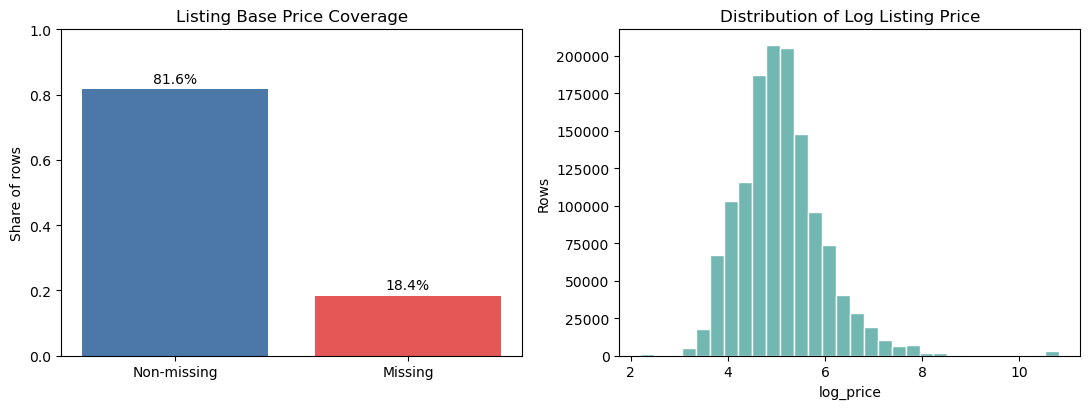

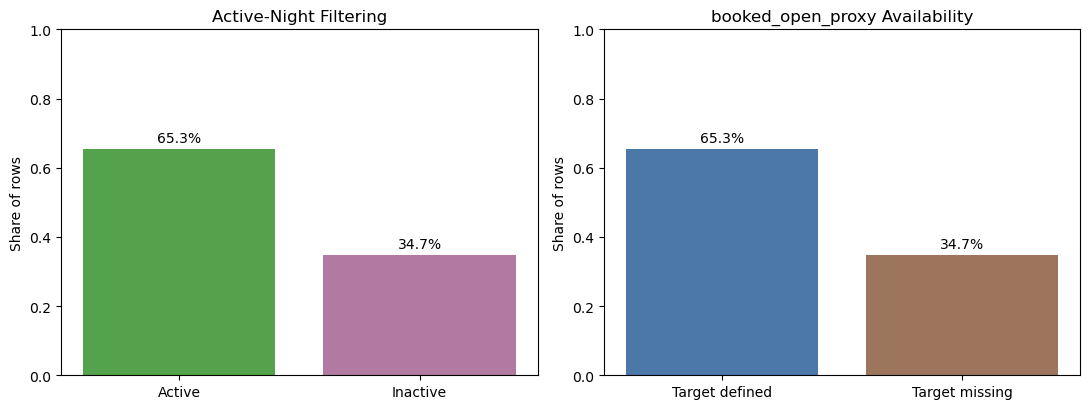

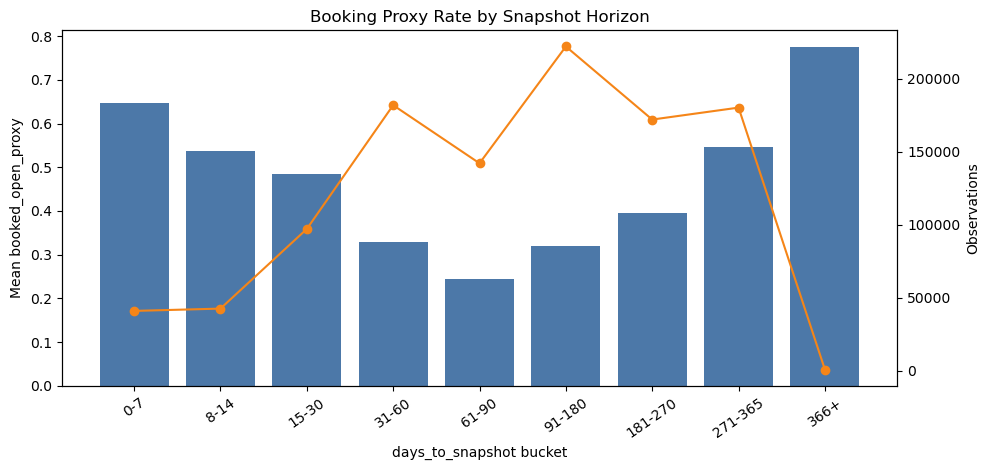

In [8]:
# Keep latest snapshot for each (listing_id, date)
panel_raw = panel_raw.sort_values(["listing_id", "date", "snapshot_date"])
panel = panel_raw.drop_duplicates(subset=["listing_id", "date"], keep="last").copy()

# Keep a fixed-size listing sample for faster modeling
if LISTING_SAMPLE_SIZE and panel["listing_id"].nunique() > LISTING_SAMPLE_SIZE:
    sampled_listings = panel["listing_id"].drop_duplicates().sample(LISTING_SAMPLE_SIZE, random_state=RANDOM_SEED)
    panel = panel[panel["listing_id"].isin(set(sampled_listings))].copy()

# --- Listing base price (extracted separately from listings.csv.gz) ---
# The calendar-level price is empty in most snapshots, so we extract the
# listing base nightly rate from listings.csv.gz (most recent non-null per listing).
listing_price_df = extract_listing_base_prices(snapshot_dirs)
panel = panel.merge(listing_price_df, on="listing_id", how="left")

panel["log_price"] = np.log1p(panel["listing_base_price"].clip(lower=0))

# Price relative to neighbourhood median (cross-sectional competitiveness)
# Use only training-year data to compute medians, avoiding look-ahead.
panel["_year_tmp"] = panel["date"].dt.year
neighbourhood_median_price = (
    panel.loc[panel["_year_tmp"] == TRAIN_YEAR]
    .groupby("neighbourhood")["listing_base_price"]
    .median()
)
panel["price_vs_neighbourhood_median"] = (
    panel["listing_base_price"] / panel["neighbourhood"].map(neighbourhood_median_price)
)
panel["price_vs_neighbourhood_median"] = (
    panel["price_vs_neighbourhood_median"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 10)
)
panel = panel.drop(columns=["_year_tmp"])

# --- Temporal features ---
panel["year"] = panel["date"].dt.year
panel["month"] = panel["date"].dt.month
panel["week_of_year"] = panel["date"].dt.isocalendar().week.astype(int)
panel["day_of_week"] = panel["date"].dt.dayofweek
panel["is_weekend"] = (panel["day_of_week"] >= 5).astype(int)

# Snapshot horizon: how many days ahead the snapshot is observing this date.
# Lets the model learn that far-out dates have lower effective booking rates
# due to observation bias (not yet booked ≠ truly available).
panel["days_to_snapshot"] = (panel["date"] - panel["snapshot_date"]).dt.days

# Fourier seasonality: cyclical encoding of day-of-year.
# Captures smooth seasonal patterns that month dummies cannot represent
# (e.g. December and January are adjacent, not maximally different).
doy = panel["date"].dt.dayofyear
panel["sin_doy"]   = np.sin(2 * np.pi * doy / 365.25)
panel["cos_doy"]   = np.cos(2 * np.pi * doy / 365.25)
panel["sin_doy_2"] = np.sin(4 * np.pi * doy / 365.25)  # 2nd harmonic
panel["cos_doy_2"] = np.cos(4 * np.pi * doy / 365.25)

# --- Listing-level activity statistics (leakage-safe: TRAIN_YEAR only) ---
panel_train_year = panel[panel["year"] == TRAIN_YEAR].copy()
listing_stats = panel_train_year.groupby("listing_id", as_index=False).agg(
    listing_obs_count=("available", "size"),
    listing_available_rate=("available", "mean")
)
panel = panel.merge(listing_stats, on="listing_id", how="left")
panel["is_actively_open_night"] = (
    (panel["listing_obs_count"] >= 30) &
    (panel["listing_available_rate"] > 0.05) &
    (panel["listing_available_rate"] < 0.95)
).fillna(False).astype(int)

# --- Target construction ---
panel["booked_open_proxy"] = np.where(
    panel["is_actively_open_night"].eq(1),
    1 - panel["available"],
    np.nan,
)

# Listing historical booking rate: what fraction of this listing's past dates
# were booked. A strong cross-sectional signal for listing popularity.
panel_train_year = panel[panel["year"] == TRAIN_YEAR].copy()
listing_booking_rate = (
    panel_train_year[panel_train_year["booked_open_proxy"].notna()]
    .groupby("listing_id")["booked_open_proxy"]
    .mean()
    .rename("listing_hist_booking_rate")
)
panel = panel.merge(listing_booking_rate, on="listing_id", how="left")

print("panel dedup shape:", panel.shape)
print("unique listings:", panel["listing_id"].nunique())
print("active-night share:", panel["is_actively_open_night"].mean().round(4))
print("target non-null rows:", panel["booked_open_proxy"].notna().sum())
print("listing_base_price coverage:", panel["listing_base_price"].notna().mean().round(4))

# Diagnostic: price coverage and transformed price distribution
price_coverage = panel["listing_base_price"].notna().mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(["Non-missing", "Missing"], [price_coverage, 1 - price_coverage], color=["#4C78A8", "#E45756"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Share of rows")
axes[0].set_title("Listing Base Price Coverage")
for i, val in enumerate([price_coverage, 1 - price_coverage]):
    axes[0].text(i, val + 0.02, f"{val:.1%}", ha="center")
axes[1].hist(panel.loc[panel["log_price"].notna(), "log_price"], bins=30, color="#72B7B2", edgecolor="white")
axes[1].set_xlabel("log_price")
axes[1].set_ylabel("Rows")
axes[1].set_title("Distribution of Log Listing Price")
fig.tight_layout()
fig.savefig(FIGS_DIR / "price_coverage_and_distribution.png", dpi=150)
plt.show()
plt.close(fig)

# Diagnostic: active-night filtering share and booking-proxy availability
active_share = panel["is_actively_open_night"].mean()
target_share = panel["booked_open_proxy"].notna().mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(["Active", "Inactive"], [active_share, 1 - active_share], color=["#54A24B", "#B279A2"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Share of rows")
axes[0].set_title("Active-Night Filtering")
for i, val in enumerate([active_share, 1 - active_share]):
    axes[0].text(i, val + 0.02, f"{val:.1%}", ha="center")
axes[1].bar(["Target defined", "Target missing"], [target_share, 1 - target_share], color=["#4C78A8", "#9D755D"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Share of rows")
axes[1].set_title("booked_open_proxy Availability")
for i, val in enumerate([target_share, 1 - target_share]):
    axes[1].text(i, val + 0.02, f"{val:.1%}", ha="center")
fig.tight_layout()
fig.savefig(FIGS_DIR / "active_night_filter_diagnostic.png", dpi=150)
plt.show()
plt.close(fig)

# Diagnostic: booking-proxy rate by snapshot horizon bucket
horizon_df = panel.loc[panel["booked_open_proxy"].notna(), ["days_to_snapshot", "booked_open_proxy"]].copy()
horizon_max = int(horizon_df["days_to_snapshot"].max())
horizon_upper = max(366, horizon_max)
horizon_bins = [-1, 7, 14, 30, 60, 90, 180, 270, 365, horizon_upper]
horizon_labels = ["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-270", "271-365", "366+"]
horizon_df["horizon_bucket"] = pd.cut(horizon_df["days_to_snapshot"], bins=horizon_bins, labels=horizon_labels, include_lowest=True)
horizon_summary = (
    horizon_df
    .groupby("horizon_bucket", as_index=False, observed=False)
    .agg(booked_rate=("booked_open_proxy", "mean"), n_obs=("booked_open_proxy", "size"))
)
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.bar(horizon_summary["horizon_bucket"].astype(str), horizon_summary["booked_rate"], color="#4C78A8")
ax1.set_ylabel("Mean booked_open_proxy")
ax1.set_xlabel("days_to_snapshot bucket")
ax1.set_title("Booking Proxy Rate by Snapshot Horizon")
ax1.tick_params(axis="x", rotation=35)
ax2 = ax1.twinx()
ax2.plot(horizon_summary["horizon_bucket"].astype(str), horizon_summary["n_obs"], color="#F58518", marker="o", linewidth=1.5)
ax2.set_ylabel("Observations")
fig.tight_layout()
fig.savefig(FIGS_DIR / "days_to_snapshot_diagnostic.png", dpi=150)
plt.show()
plt.close(fig)

## 4b) Build Event Proxy Features
Build the processed event proxy file from raw Los Angeles event sources before the optional event-controls merge.


In [9]:
# Rebuild the processed event proxy used later in optional event-controls merges.
raw_events_dir = RAW_DIR / "events"
event_proxy_start = pd.to_datetime(panel["date"].min()).normalize()
event_proxy_end = pd.to_datetime(panel["date"].max()).normalize()

event_proxy_df, event_proxy_audit = build_event_proxy_features(
    raw_events_dir,
    event_proxy_start,
    event_proxy_end,
    EVENT_PROXY_PATH,
)

print("Saved event proxy features:", EVENT_PROXY_PATH)
print(event_proxy_audit)
event_proxy_df.head()


Saved event proxy features: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/event_proxies_daily_features.csv
{'event_proxy_start': '2025-03-02', 'event_proxy_end': '2026-12-10', 'n_rows': 649, 'ticketmaster_source_files': 4, 'ticketmaster_event_days': 252, 'city_calendar_event_days': 84, 'tse_permit_event_days': 649}


,date,event_count_total,event_count_sofi,event_count_sports,event_count_music,event_count_high_intensity,event_count_city_calendar,event_count_tse_permit,is_any_event_day,is_sofi_event_day,is_sports_event_day,is_music_event_day,is_high_intensity_event_day,is_city_calendar_event_day,is_tse_permit_event_day
0,2025-03-02,0,0,0,0,0,0,13,0,0,0,0,0,0,1
1,2025-03-03,0,0,0,0,0,0,5,0,0,0,0,0,0,1
2,2025-03-04,0,0,0,0,0,0,2,0,0,0,0,0,0,1
3,2025-03-05,0,0,0,0,0,0,3,0,0,0,0,0,0,1
4,2025-03-06,0,0,0,0,0,0,4,0,0,0,0,0,0,1


In [10]:
# Merge weather + holidays
weather = load_weather(WEATHER_PATH)
holidays = load_holidays(HOLIDAY_DIR, HOLIDAY_YEARS)

merge_audit = {
    "rows_before_weather": int(len(panel)),
}
if "event_proxy_audit" in globals():
    merge_audit["event_proxy_build"] = event_proxy_audit

panel = panel.merge(weather, on="date", how="left", validate="many_to_one")
merge_audit["rows_after_weather"] = int(len(panel))

if "weather_source" in panel.columns:
    merge_audit["weather_source_counts"] = panel["weather_source"].fillna("unknown").value_counts().to_dict()

if USE_2025_MONTHLY_WEATHER_SCENARIO:
    panel, weather_fill_audit = apply_2025_monthly_weather_scenario(
        panel, ["temp_max", "temp_min", "precipitation_sum"]
    )
    merge_audit["weather_2025_monthly_scenario"] = weather_fill_audit

panel = panel.merge(holidays, on="date", how="left", validate="many_to_one")
merge_audit["rows_after_holidays"] = int(len(panel))

# feature engineering: holiday indicator defaults
panel["is_holiday"] = panel["is_holiday"].fillna(0).astype(int)
panel["holiday_type"] = panel["holiday_type"].fillna("none")

# Optional event-count controls (only if clean)
use_events = False
if USE_OPTIONAL_EVENT_CONTROLS and EVENT_PROXY_PATH.exists():
    event_cols = ["date", "event_count_total", "event_count_sports", "event_count_music", "event_count_city_calendar", "event_count_tse_permit"]
    event_df = pd.read_csv(EVENT_PROXY_PATH, usecols=lambda c: c in event_cols)
    event_df["date"] = pd.to_datetime(event_df["date"])

    panel_with_events = panel.merge(event_df, on="date", how="left", validate="many_to_one")
    missing_share = panel_with_events[["event_count_total", "event_count_sports", "event_count_music", "event_count_city_calendar", "event_count_tse_permit"]].isna().mean().max()

    if missing_share <= MAX_EVENT_MISSING_SHARE:
        panel = panel_with_events
        use_events = True
    else:
        panel["event_count_total"] = np.nan
        panel["event_count_sports"] = np.nan
        panel["event_count_music"] = np.nan
        panel["event_count_city_calendar"] = np.nan
        panel["event_count_tse_permit"] = np.nan
else:
    panel["event_count_total"] = np.nan
    panel["event_count_sports"] = np.nan
    panel["event_count_music"] = np.nan
    panel["event_count_city_calendar"] = np.nan
    panel["event_count_tse_permit"] = np.nan

merge_audit["optional_event_controls_included"] = bool(use_events)
print("Optional event controls included:", use_events)


Optional event controls included: False


## 5) Curate Final Dataset Columns


In [11]:
# Ensure required output columns exist
for col in MODEL_BASE_COLS:
    if col not in panel.columns:
        panel[col] = np.nan

# feature engineering: final curated modeling table
curated = panel[MODEL_BASE_COLS + ["listing_available_rate", "listing_obs_count"]].copy()

# Optional lightweight cleaning (do not impute target)
num_fill_zero = EVENT_CONTROL_COLS if INCLUDE_EVENT_CONTROLS else []
for c in num_fill_zero:
    if c in curated.columns:
        curated[c] = curated[c].fillna(0)

curated = curated.sort_values(["date", "listing_id"]).reset_index(drop=True)
print("curated shape:", curated.shape)
curated.head()


curated shape: (1651366, 43)


,listing_id,date,snapshot_date,available,booked_open_proxy,is_actively_open_night,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bathrooms_std,bedrooms,beds,amenities_count,listing_minimum_nights,listing_maximum_nights,host_is_superhost,instant_bookable,number_of_reviews,review_scores_rating,listing_base_price,log_price,price_vs_neighbourhood_median,year,month,week_of_year,day_of_week,is_weekend,days_to_snapshot,sin_doy,cos_doy,sin_doy_2,cos_doy_2,temp_max,temp_min,precipitation_sum,is_holiday,holiday_type,listing_hist_booking_rate,listing_available_rate,listing_obs_count
0,45392,2025-03-02,2025-03-01,0,1.0,1,34.106320,-118.223610,Mount Washington,Private room in home,Private room,2,1.0,1.0,2.0,31,30,30,0.0,0,28,4.85,65.0,4.189655,0.371429,2025,3,9,6,1,1,0.867099,0.498137,0.863867,-0.50372,17.1,9.8,1.4,0,none,0.114754,0.885246,305
1,64574,2025-03-02,2025-03-01,1,NaN,0,34.127690,-118.321670,Hollywood Hills,Entire home,Entire home/apt,4,2.0,2.0,0.0,18,30,84,0.0,0,16,4.94,335.0,5.817111,1.753927,2025,3,9,6,1,1,0.867099,0.498137,0.863867,-0.50372,17.1,9.8,1.4,0,none,NaN,0.967213,305
2,862186,2025-03-02,2025-03-01,1,0.0,1,34.191340,-118.522820,Reseda,Entire guesthouse,Entire home/apt,2,1.0,1.0,1.0,55,1,1125,1.0,0,667,4.98,260.0,5.564520,1.171171,2025,3,9,6,1,1,0.867099,0.498137,0.863867,-0.50372,17.1,9.8,1.4,0,none,0.334426,0.665574,305
3,1172076,2025-03-02,2025-03-01,0,1.0,1,34.046820,-118.529200,Pacific Palisades,Entire rental unit,Entire home/apt,5,1.0,2.0,2.0,28,30,300,1.0,0,14,4.86,254.0,5.541264,0.684636,2025,3,9,6,1,1,0.867099,0.498137,0.863867,-0.50372,17.1,9.8,1.4,0,none,0.111475,0.888525,305
4,1233296,2025-03-02,2025-03-01,1,0.0,1,34.078485,-118.116297,Alhambra,Private room in home,Private room,2,1.5,1.0,2.0,34,7,1125,0.0,0,62,4.41,48.0,3.891820,0.484848,2025,3,9,6,1,1,0.867099,0.498137,0.863867,-0.50372,17.1,9.8,1.4,0,none,0.114754,0.885246,305


## 6) Data Quality Checks
- missingness
- duplicates
- date range
- merge integrity


QC summary:
- n_rows: 1651366
- n_listings: 3000
- date_min: 2025-03-02
- date_max: 2026-12-10
- duplicate_listing_date_rows: 0
- target_non_null_rows: 1078516
- target_positive_rate_on_non_null: 0.397206902818317
- active_night_share: 0.6531053685252088
- leakage_drop_cols_defined: ['available', 'booked_open_proxy', 'is_actively_open_night', 'listing_available_rate', 'listing_obs_count']
- merge_audit: {"rows_before_weather": 1651366, "event_proxy_build": {"event_proxy_start": "2025-03-02", "event_proxy_end": "2026-12-10", "n_rows": 649, "ticketmaster_source_files": 4, "ticketmaster_event_days": 252, "city_calendar_event_days": 84, "tse_permit_event_days": 649}, "rows_after_weather": 1651366, "weather_source_counts": {"observed": 975039, "scenario_2025_monthly_avg": 676327}, "rows_after_holidays": 1651366, "optional_event_controls_included": false}
- row_audit: {"snapshot_count": 5, "rows_calendar_total": 66418519, "rows_after_listing_merge_total": 66418519}


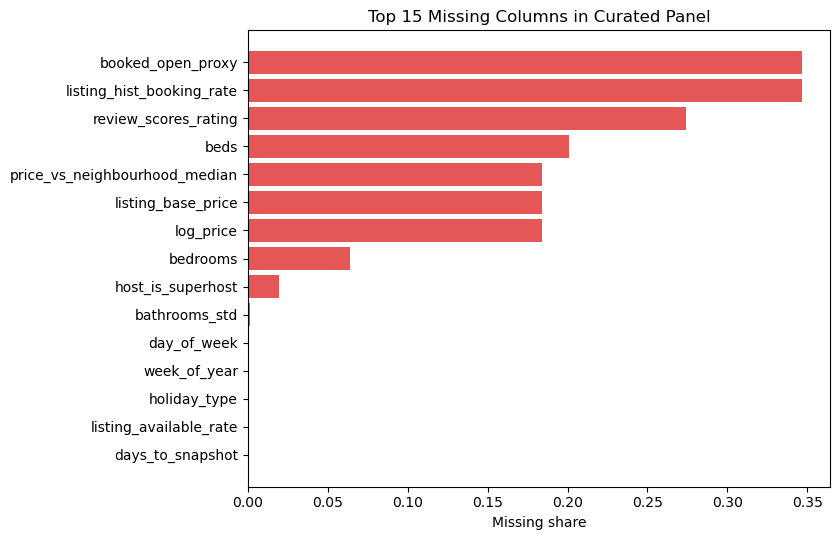

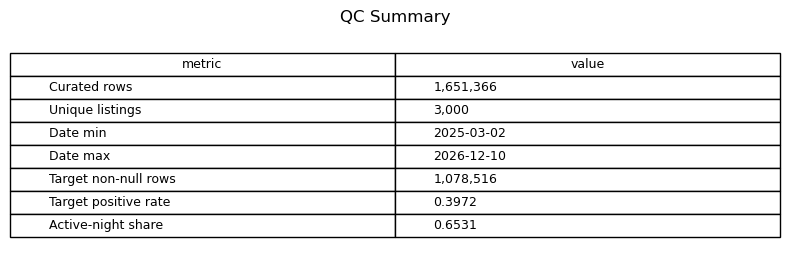

In [12]:
qc = {}

qc["n_rows"] = int(len(curated))
qc["n_listings"] = int(curated["listing_id"].nunique())
qc["date_min"] = str(curated["date"].min().date())
qc["date_max"] = str(curated["date"].max().date())
qc["duplicate_listing_date_rows"] = int(curated.duplicated(subset=["listing_id", "date"]).sum())
qc["target_non_null_rows"] = int(curated["booked_open_proxy"].notna().sum())
qc["target_positive_rate_on_non_null"] = float(curated.loc[curated["booked_open_proxy"].notna(), "booked_open_proxy"].mean())
qc["active_night_share"] = float(curated["is_actively_open_night"].mean())
qc["leakage_drop_cols_defined"] = LEAKAGE_DROP_COLS
qc["merge_audit"] = merge_audit
qc["row_audit"] = row_audit

missingness = curated.isna().mean().sort_values(ascending=False).rename("missing_share").reset_index()
missingness = missingness.rename(columns={"index": "column"})

print("QC summary:")
for k, v in qc.items():
    if isinstance(v, dict):
        print(f"- {k}: {json.dumps(v)}")
    else:
        print(f"- {k}: {v}")

missingness.head(20)

# Diagnostic: top missing columns in curated panel
top_missing = missingness.head(15).sort_values("missing_share", ascending=True)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(top_missing["column"], top_missing["missing_share"], color="#E45756")
ax.set_xlabel("Missing share")
ax.set_title("Top 15 Missing Columns in Curated Panel")
fig.tight_layout()
fig.savefig(FIGS_DIR / "missingness_top15.png", dpi=150)
plt.show()
plt.close(fig)

# Diagnostic: compact QC summary table for appendix/reference
qc_display = pd.DataFrame({
    "metric": [
        "Curated rows", "Unique listings", "Date min", "Date max",
        "Target non-null rows", "Target positive rate", "Active-night share"
    ],
    "value": [
        f"{qc['n_rows']:,}", f"{qc['n_listings']:,}", qc['date_min'], qc['date_max'],
        f"{qc['target_non_null_rows']:,}", f"{qc['target_positive_rate_on_non_null']:.4f}", f"{qc['active_night_share']:.4f}"
    ]
})
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.axis("off")
tbl = ax.table(cellText=qc_display.values, colLabels=qc_display.columns, loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.3)
ax.set_title("QC Summary")
fig.tight_layout()
fig.savefig(FIGS_DIR / "qc_summary_table.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## 7) Save Curated Dataset and Audit Log


In [13]:
curated.to_csv(CURATED_PATH, index=False, compression="gzip")
missingness.to_csv(MISSINGNESS_PATH, index=False)
with open(AUDIT_PATH, "w") as f:
    json.dump(qc, f, indent=2)

print("Saved:")
print("-", CURATED_PATH)
print("-", MISSINGNESS_PATH)
print("-", AUDIT_PATH)


Saved:
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/curated_panel.csv.gz
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/logs/missingness.csv
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/logs/curation_audit.json


## 8) Exported Report Assets
- `data/processed/curated_panel.csv.gz`
- `data/processed/logs/missingness.csv`
- `data/processed/logs/curation_audit.json`


## 9) Chronological Train/Validation/Test Split
Use strict date-based splitting to avoid look-ahead leakage.


Rows train/val/test: 525382 305157 247977
Date ranges:
 train: 2025-03-02 00:00:00 -> 2025-12-31 00:00:00
 val  : 2026-01-01 00:00:00 -> 2026-06-21 00:00:00
 test : 2026-06-22 00:00:00 -> 2026-12-10 00:00:00


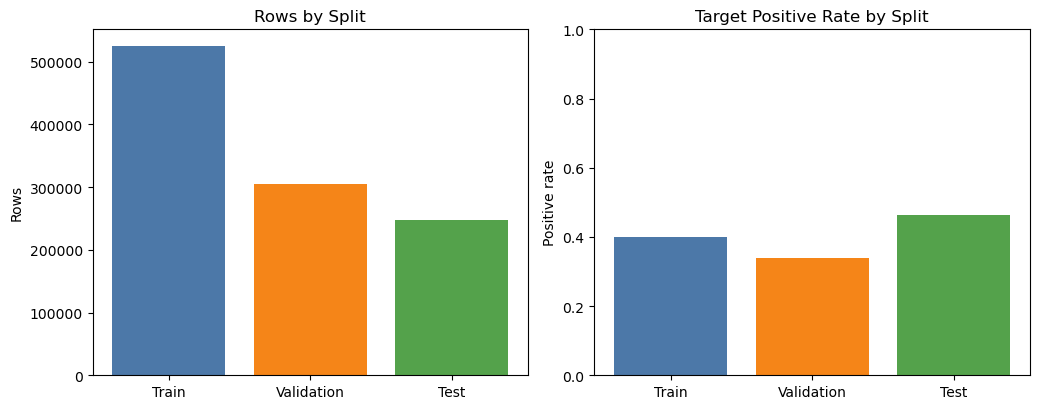

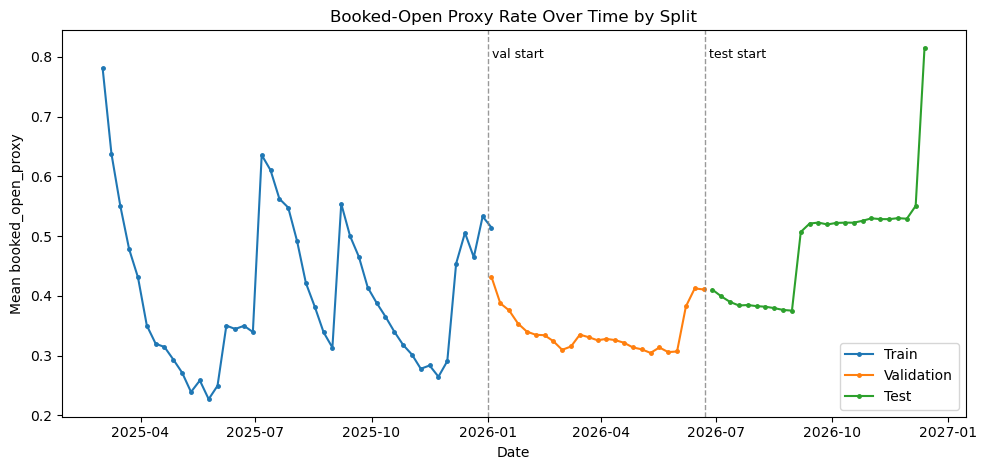

In [14]:
SPLIT_DIR = OUT_DIR / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = SPLIT_DIR / "train.csv.gz"
VAL_PATH = SPLIT_DIR / "val.csv.gz"
TEST_PATH = SPLIT_DIR / "test.csv.gz"

# Modeling rows: only rows with valid booked_open_proxy
model_df = curated[curated["booked_open_proxy"].notna()].copy()
model_df["booked_open_proxy"] = model_df["booked_open_proxy"].astype(int)

# Strict chronology: train on 2025, validate/test on 2026
train_df = model_df[model_df["date"].dt.year == TRAIN_YEAR].copy()
vt_df = model_df[model_df["date"].dt.year == VAL_TEST_YEAR].copy()

if train_df.empty:
    raise RuntimeError(f"Train split is empty for TRAIN_YEAR={TRAIN_YEAR}")
if vt_df.empty:
    raise RuntimeError(f"Validation/test candidate split is empty for VAL_TEST_YEAR={VAL_TEST_YEAR}")

vt_dates = np.array(sorted(vt_df["date"].unique()))
if len(vt_dates) < 2:
    raise RuntimeError("Not enough 2026 dates to create val/test splits")

val_end_idx = int(np.floor(VAL_SHARE_WITHIN_2026 * len(vt_dates)))
val_end_idx = max(1, min(val_end_idx, len(vt_dates) - 1))

val_dates = set(vt_dates[:val_end_idx])
test_dates = set(vt_dates[val_end_idx:])

val_df = vt_df[vt_df["date"].isin(val_dates)].copy()
test_df = vt_df[vt_df["date"].isin(test_dates)].copy()

# Split integrity checks
train_dates = set(train_df["date"].unique())
assert len(train_dates & val_dates) == 0
assert len(train_dates & test_dates) == 0
assert len(val_dates & test_dates) == 0

train_keys = train_df[["listing_id", "date"]].drop_duplicates()
val_keys = val_df[["listing_id", "date"]].drop_duplicates()
test_keys = test_df[["listing_id", "date"]].drop_duplicates()

assert train_keys.merge(val_keys, on=["listing_id", "date"], how="inner").empty
assert train_keys.merge(test_keys, on=["listing_id", "date"], how="inner").empty
assert val_keys.merge(test_keys, on=["listing_id", "date"], how="inner").empty

print("Rows train/val/test:", len(train_df), len(val_df), len(test_df))
print("Date ranges:")
print(" train:", train_df["date"].min(), "->", train_df["date"].max())
print(" val  :", val_df["date"].min(), "->", val_df["date"].max())
print(" test :", test_df["date"].min(), "->", test_df["date"].max())

# Diagnostic: split composition summary
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "positive_rate": [train_df["booked_open_proxy"].mean(), val_df["booked_open_proxy"].mean(), test_df["booked_open_proxy"].mean()],
})
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].bar(split_summary["split"], split_summary["rows"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_ylabel("Rows")
axes[0].set_title("Rows by Split")
axes[1].bar(split_summary["split"], split_summary["positive_rate"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_ylabel("Positive rate")
axes[1].set_ylim(0, 1)
axes[1].set_title("Target Positive Rate by Split")
fig.tight_layout()
fig.savefig(FIGS_DIR / "split_composition_summary.png", dpi=150)
plt.show()
plt.close(fig)

# Diagnostic: time-based target-rate shift over chronological splits
split_rate_df = pd.concat([
    train_df[["date", "booked_open_proxy"]].assign(split="Train"),
    val_df[["date", "booked_open_proxy"]].assign(split="Validation"),
    test_df[["date", "booked_open_proxy"]].assign(split="Test"),
], ignore_index=True)
split_rate_df["date"] = pd.to_datetime(split_rate_df["date"])
split_rate_weekly = (
    split_rate_df
    .groupby(["split", pd.Grouper(key="date", freq="W")], as_index=False)
    .agg(booked_rate=("booked_open_proxy", "mean"), n_obs=("booked_open_proxy", "size"))
)
plt.figure(figsize=(10, 4.8))
for split_name, color in [("Train", "#1f77b4"), ("Validation", "#ff7f0e"), ("Test", "#2ca02c")]:
    d = split_rate_weekly[split_rate_weekly["split"] == split_name]
    plt.plot(d["date"], d["booked_rate"], marker="o", markersize=2.5, linewidth=1.5, label=split_name, color=color)
plt.axvline(val_df["date"].min(), linestyle="--", linewidth=1, color="gray", alpha=0.8)
plt.axvline(test_df["date"].min(), linestyle="--", linewidth=1, color="gray", alpha=0.8)
plt.text(val_df["date"].min(), split_rate_weekly["booked_rate"].max(), " val start", va="top", ha="left", fontsize=9)
plt.text(test_df["date"].min(), split_rate_weekly["booked_rate"].max(), " test start", va="top", ha="left", fontsize=9)
plt.ylabel("Mean booked_open_proxy")
plt.xlabel("Date")
plt.title("Booked-Open Proxy Rate Over Time by Split")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "target_rate_over_time_by_split_diagnostic.png", dpi=150)
plt.show()
plt.close()


In [15]:
# Persist splits
train_df.to_csv(TRAIN_PATH, index=False, compression="gzip")
val_df.to_csv(VAL_PATH, index=False, compression="gzip")
test_df.to_csv(TEST_PATH, index=False, compression="gzip")

print("Saved splits:")
print("-", TRAIN_PATH)
print("-", VAL_PATH)
print("-", TEST_PATH)


Saved splits:
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/splits/train.csv.gz
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/splits/val.csv.gz
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/splits/test.csv.gz


## 10) Modeling Setup (Features, Preprocessing, Metrics)
Use a standardized workflow: stepwise preprocessing, pipeline-based model training, validation-based tuning, and consistent classification diagnostics.


In [16]:
# === Step 1: imports and output paths ===
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

MODEL_OUTPUT_DIR = OUT_DIR / "model_outputs"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = MODEL_OUTPUT_DIR / "availability_metrics.json"
PRED_PATH = MODEL_OUTPUT_DIR / "test_predictions.csv.gz"
SEGMENT_PATH = MODEL_OUTPUT_DIR / "segment_metrics.csv"

# Optional model dev cap for faster iteration
MODEL_DEV_MODE = False
MODEL_MAX_TRAIN_ROWS = 400_000 if MODEL_DEV_MODE else None

# === Step 2: define feature groups and target ===
cat_cols = [
    "neighbourhood", "property_type", "room_type", "holiday_type", "month"
]
base_num_cols = [
    "latitude", "longitude",
    "accommodates", "bathrooms_std", "bedrooms", "beds", "amenities_count",
    "listing_minimum_nights", "number_of_reviews", "review_scores_rating",
    # Listing attributes
    "host_is_superhost", "instant_bookable",
    # Price features
    "log_price", "price_vs_neighbourhood_median",
    # Temporal features
    "year", "week_of_year", "day_of_week", "is_weekend", "is_holiday",
    "days_to_snapshot",
    "sin_doy", "cos_doy", "sin_doy_2", "cos_doy_2",
    # Panel features
    "listing_hist_booking_rate",
]
num_cols = base_num_cols + (EVENT_CONTROL_COLS if INCLUDE_EVENT_CONTROLS else [])

feature_cols = num_cols + cat_cols
target_col = "booked_open_proxy"

# === Step 3: leakage guard + modeling sample cleanup ===
for leak_col in LEAKAGE_DROP_COLS:
    if leak_col in feature_cols:
        raise ValueError(f"Leakage column in feature set: {leak_col}")

# Drop rows missing target
train_df = train_df[train_df[target_col].notna()].copy()
val_df = val_df[val_df[target_col].notna()].copy()
test_df = test_df[test_df[target_col].notna()].copy()

# Ensure calendar features exist (safe for out-of-order execution)
for _df in [train_df, val_df, test_df]:
    _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
    if "year" not in _df.columns:
        _df["year"] = _df["date"].dt.year
    if "month" not in _df.columns:
        _df["month"] = _df["date"].dt.month
    if "week_of_year" not in _df.columns:
        _df["week_of_year"] = _df["date"].dt.isocalendar().week.astype(int)
    if "day_of_week" not in _df.columns:
        _df["day_of_week"] = _df["date"].dt.dayofweek
    if "is_weekend" not in _df.columns:
        _df["is_weekend"] = (_df["day_of_week"] >= 5).astype(int)

if MODEL_MAX_TRAIN_ROWS and len(train_df) > MODEL_MAX_TRAIN_ROWS:
    train_df = train_df.sample(MODEL_MAX_TRAIN_ROWS, random_state=RANDOM_SEED)

# Drop numeric features that are completely missing in training window
available_num_cols = [c for c in num_cols if train_df[c].notna().any()]
dropped_all_missing_num_cols = sorted(set(num_cols) - set(available_num_cols))
if dropped_all_missing_num_cols:
    print("Dropping all-missing numeric features:", dropped_all_missing_num_cols)
num_cols = available_num_cols
feature_cols = num_cols + cat_cols

# Finite-value guard + outlier clipping based on train quantiles
for _df in [train_df, val_df, test_df]:
    _df[num_cols] = _df[num_cols].replace([np.inf, -np.inf], np.nan)

clip_bounds = {}
for c in num_cols:
    q01 = train_df[c].quantile(0.01)
    q99 = train_df[c].quantile(0.99)
    if pd.notna(q01) and pd.notna(q99):
        clip_bounds[c] = (q01, q99)

for c, (lo, hi) in clip_bounds.items():
    train_df[c] = train_df[c].clip(lo, hi)
    val_df[c] = val_df[c].clip(lo, hi)
    test_df[c] = test_df[c].clip(lo, hi)

X_train = train_df[feature_cols]
y_train = train_df[target_col].astype(int)
X_val = val_df[feature_cols]
y_val = val_df[target_col].astype(int)
X_test = test_df[feature_cols]
y_test = test_df[target_col].astype(int)

# === Step 4: sklearn pipeline preprocessing block ===
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
        ]), cat_cols),
    ],
    remainder="drop",
)


# === Step 5: reusable classification metric helper ===
def compute_metrics(y_true, p_hat, threshold=0.5):
    y_true = pd.Series(y_true)
    p_hat = np.asarray(p_hat)
    p_hat = np.nan_to_num(p_hat, nan=0.5, posinf=1.0, neginf=0.0)
    p_hat = np.clip(p_hat, 1e-6, 1 - 1e-6)
    y_pred = (p_hat >= threshold).astype(int)

    if y_true.nunique() < 2:
        roc_auc = np.nan
        pr_auc = np.nan
    else:
        roc_auc = float(roc_auc_score(y_true, p_hat))
        pr_auc = float(average_precision_score(y_true, p_hat))

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "brier": float(brier_score_loss(y_true, p_hat)),
        "threshold": float(threshold),
    }

## 11) Train Baseline L1 Logistic and XGBoost


In [17]:
# === Step 0: expanding-window backtest folds over 2025 training dates ===
# Shared by both logistic C tuning and XGBoost hyperparameter search.
train_bt = train_df.sort_values("date").copy()
train_bt_dates = np.array(sorted(train_bt["date"].unique()))

n_bt_dates = len(train_bt_dates)
if n_bt_dates < 12:
    raise RuntimeError("Not enough 2025 dates for rolling backtests")

cut_1 = int(np.floor(0.50 * n_bt_dates))
cut_2 = int(np.floor(0.65 * n_bt_dates))
cut_3 = int(np.floor(0.80 * n_bt_dates))
cut_4 = int(np.floor(0.90 * n_bt_dates))

cut_1 = max(5, min(cut_1, n_bt_dates - 4))
cut_2 = max(cut_1 + 2, min(cut_2, n_bt_dates - 3))
cut_3 = max(cut_2 + 2, min(cut_3, n_bt_dates - 2))
cut_4 = max(cut_3 + 1, min(cut_4, n_bt_dates - 1))

bt_folds = [
    (set(train_bt_dates[:cut_1]), set(train_bt_dates[cut_1:cut_2])),
    (set(train_bt_dates[:cut_2]), set(train_bt_dates[cut_2:cut_3])),
    (set(train_bt_dates[:cut_3]), set(train_bt_dates[cut_3:cut_4])),
]

print(f"Backtest folds: {len(bt_folds)} folds over {n_bt_dates} unique 2025 dates")

# === Step 1: L1 Logistic with backtest-tuned C ===
C_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

logit_best_bt_pr = -1.0
logit_best_C = 0.01
logit_bt_results = []

for C_val in C_grid:
    fold_scores = []
    for tr_dates, va_dates in bt_folds:
        bt_tr = train_bt[train_bt["date"].isin(tr_dates)]
        bt_va = train_bt[train_bt["date"].isin(va_dates)]
        if bt_tr.empty or bt_va.empty:
            continue

        X_bt_tr = bt_tr[feature_cols]
        y_bt_tr = bt_tr[target_col].astype(int)
        X_bt_va = bt_va[feature_cols]
        y_bt_va = bt_va[target_col].astype(int)

        logit_try = Pipeline([
            ("preprocess", preprocess),
            ("clf", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=C_val,
                max_iter=5000,
                random_state=RANDOM_SEED,
            )),
        ])

        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            logit_try.fit(X_bt_tr, y_bt_tr)
            p_bt_va = logit_try.predict_proba(X_bt_va)[:, 1]

        score = average_precision_score(y_bt_va, p_bt_va) if y_bt_va.nunique() > 1 else np.nan
        fold_scores.append(score)

    valid_scores = [s for s in fold_scores if pd.notna(s)]
    mean_bt_pr = float(np.mean(valid_scores)) if valid_scores else np.nan
    logit_bt_results.append({"C": C_val, "mean_bt_pr_auc": mean_bt_pr, "n_folds": len(valid_scores)})

    if pd.notna(mean_bt_pr) and mean_bt_pr > logit_best_bt_pr:
        logit_best_bt_pr = mean_bt_pr
        logit_best_C = C_val

print(f"Best logistic C (backtest PR-AUC): {logit_best_C} | mean PR-AUC: {logit_best_bt_pr:.6f}")

# Fit final logistic on full 2025 train with selected C
logit_l1 = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=logit_best_C,
        max_iter=5000,
        random_state=RANDOM_SEED,
    )),
])

with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
    logit_l1.fit(X_train, y_train)
    p_val_logit = logit_l1.predict_proba(X_val)[:, 1]
    p_test_logit = logit_l1.predict_proba(X_test)[:, 1]

# === Step 2: XGBoost hyperparameter selection with rolling 2025 backtests ===
from itertools import product as itertools_product

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [5, 10],
}

xgb_grid_keys = list(xgb_param_grid.keys())
xgb_grid_combos = list(itertools_product(*[xgb_param_grid[k] for k in xgb_grid_keys]))
print(f"XGBoost grid: {len(xgb_grid_combos)} combos x {len(bt_folds)} folds = {len(xgb_grid_combos) * len(bt_folds)} fits")

xgb_bt_results = []
xgb_best_bt_pr = -1.0
xgb_best_params = {
    "n_estimators": 300, "max_depth": 6, "learning_rate": 0.05,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 10,
}

for combo in xgb_grid_combos:
    params = dict(zip(xgb_grid_keys, combo))
    fold_scores = []
    for tr_dates, va_dates in bt_folds:
        bt_tr = train_bt[train_bt["date"].isin(tr_dates)]
        bt_va = train_bt[train_bt["date"].isin(va_dates)]
        if bt_tr.empty or bt_va.empty:
            continue

        X_bt_tr = bt_tr[feature_cols]
        y_bt_tr = bt_tr[target_col].astype(int)
        X_bt_va = bt_va[feature_cols]
        y_bt_va = bt_va[target_col].astype(int)

        xgb_try = Pipeline([
            ("preprocess", preprocess),
            ("clf", XGBClassifier(
                random_state=RANDOM_SEED,
                eval_metric="logloss",
                verbosity=0,
                **params,
            )),
        ])

        xgb_try.fit(X_bt_tr, y_bt_tr)
        p_bt_va = xgb_try.predict_proba(X_bt_va)[:, 1]
        score = average_precision_score(y_bt_va, p_bt_va) if y_bt_va.nunique() > 1 else np.nan
        fold_scores.append(score)

    valid_scores = [s for s in fold_scores if pd.notna(s)]
    mean_bt_pr = float(np.mean(valid_scores)) if valid_scores else np.nan
    xgb_bt_results.append({**params, "mean_bt_pr_auc": mean_bt_pr, "n_folds": len(valid_scores)})

    if pd.notna(mean_bt_pr) and mean_bt_pr > xgb_best_bt_pr:
        xgb_best_bt_pr = mean_bt_pr
        xgb_best_params = params.copy()

xgb_bt_results_df = pd.DataFrame(xgb_bt_results).sort_values(
    ["mean_bt_pr_auc", "n_folds"], ascending=[False, False]
)

print(f"Best XGBoost params (backtest PR-AUC): {xgb_best_params}")
print(f"  mean backtest PR-AUC: {xgb_best_bt_pr:.6f}")

# Fit final XGBoost on full 2025 train with selected params
xgb_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", XGBClassifier(
        random_state=RANDOM_SEED,
        eval_metric="logloss",
        verbosity=0,
        **xgb_best_params,
    )),
])
xgb_model.fit(X_train, y_train)
p_val_xgb = xgb_model.predict_proba(X_val)[:, 1]
p_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_val_pr_2026 = average_precision_score(y_val, p_val_xgb) if y_val.nunique() > 1 else np.nan

# === Step 3: threshold selection on validation (maximize F1) ===
threshold_grid = np.round(np.linspace(0.10, 0.90, 41), 2)

best_logit_threshold = 0.5
best_logit_f1 = -1.0
for t in threshold_grid:
    f1_t = f1_score(y_val, (p_val_logit >= t).astype(int), zero_division=0)
    if f1_t > best_logit_f1:
        best_logit_f1 = float(f1_t)
        best_logit_threshold = float(t)

best_xgb_threshold = 0.5
best_xgb_f1 = -1.0
for t in threshold_grid:
    f1_t = f1_score(y_val, (p_val_xgb >= t).astype(int), zero_division=0)
    if f1_t > best_xgb_f1:
        best_xgb_f1 = float(f1_t)
        best_xgb_threshold = float(t)

# === Step 4: final evaluation with selected thresholds ===
logit_val_metrics = compute_metrics(y_val, p_val_logit, threshold=best_logit_threshold)
logit_test_metrics = compute_metrics(y_test, p_test_logit, threshold=best_logit_threshold)
xgb_val_metrics = compute_metrics(y_val, p_val_xgb, threshold=best_xgb_threshold)
xgb_test_metrics = compute_metrics(y_test, p_test_xgb, threshold=best_xgb_threshold)

print(f"\nBest logistic C: {logit_best_C} | threshold (val F1): {best_logit_threshold}")
print(f"Best XGBoost params: {xgb_best_params}")
print(f"  XGBoost 2026 val PR-AUC: {round(float(xgb_val_pr_2026), 6) if pd.notna(xgb_val_pr_2026) else np.nan}")
print(f"  XGBoost threshold (val F1): {best_xgb_threshold}")
print(f"\nL1 Logistic (val):  {logit_val_metrics}")
print(f"L1 Logistic (test): {logit_test_metrics}")
print(f"XGBoost (val):  {xgb_val_metrics}")
print(f"XGBoost (test): {xgb_test_metrics}")

Backtest folds: 3 folds over 305 unique 2025 dates
Best logistic C (backtest PR-AUC): 0.001 | mean PR-AUC: 0.710707
XGBoost grid: 54 combos x 3 folds = 162 fits
Best XGBoost params (backtest PR-AUC): {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}
  mean backtest PR-AUC: 0.796463

Best logistic C: 0.001 | threshold (val F1): 0.36
Best XGBoost params: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}
  XGBoost 2026 val PR-AUC: 0.602167
  XGBoost threshold (val F1): 0.34

L1 Logistic (val):  {'roc_auc': 0.6464643697684144, 'pr_auc': 0.5045579553054974, 'precision': 0.41413145022310677, 'recall': 0.6875487693271037, 'f1': 0.5169114664812562, 'brier': 0.24813859947602024, 'threshold': 0.36}
L1 Logistic (test): {'roc_auc': 0.5479511116980078, 'pr_auc': 0.5182866114463432, 'precision': 0.4953431251339367, 'recall': 0.5245618322742825, 'f1':

## 12) Save Metrics and Segment Comparison


In [18]:
# === Step 1: persist model metrics ===
metrics = {
    "task": "availability_proxy_classification",
    "include_event_controls": bool(INCLUDE_EVENT_CONTROLS),
    "dataset": {
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
        "train_positive_rate": float(y_train.mean()),
        "val_positive_rate": float(y_val.mean()),
        "test_positive_rate": float(y_test.mean()),
    },
    "baseline_logistic_l1": {
        "best_C": float(logit_best_C),
        "best_threshold": float(best_logit_threshold),
        "val_metrics": logit_val_metrics,
        "test_metrics": logit_test_metrics,
    },
    "xgboost_classifier": {
        "best_params": xgb_best_params,
        "best_threshold": float(best_xgb_threshold),
        "val_metrics": xgb_val_metrics,
        "test_metrics": xgb_test_metrics,
    },
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)

# === Step 2: persist test-set predictions ===
id_cols = ["listing_id", "date", "neighbourhood", "room_type", "property_type", "is_weekend", "is_holiday"]
pred_base = test_df[id_cols].copy()
pred_base["actual"] = y_test.values
pred_base["p_booked_logit_l1"] = p_test_logit
pred_base["p_booked_xgb"] = p_test_xgb

# Long format for report curves/calibration
pred_long = pd.concat([
    pred_base[id_cols + ["actual"]].assign(model="logistic_l1", prob=pred_base["p_booked_logit_l1"]),
    pred_base[id_cols + ["actual"]].assign(model="xgboost", prob=pred_base["p_booked_xgb"]),
], ignore_index=True)

pred_long.to_csv(PRED_PATH, index=False, compression="gzip")

# === Step 3: segment-level performance table ===
segment_cols = ["neighbourhood", "room_type", "is_weekend", "is_holiday"]
segment_rows = []
for seg in segment_cols:
    for seg_val, grp in pred_base.groupby(seg):
        if len(grp) < 100:
            continue
        row = {
            "segment": seg,
            "segment_value": str(seg_val),
            "n_obs": int(len(grp)),
            "positive_rate": float(grp["actual"].mean()),
        }
        row.update({f"logit_{k}": v for k, v in compute_metrics(grp["actual"], grp["p_booked_logit_l1"], threshold=best_logit_threshold).items()})
        row.update({f"xgb_{k}": v for k, v in compute_metrics(grp["actual"], grp["p_booked_xgb"], threshold=best_xgb_threshold).items()})
        segment_rows.append(row)

segment_df = pd.DataFrame(segment_rows).sort_values(["segment", "n_obs"], ascending=[True, False])
segment_df.to_csv(SEGMENT_PATH, index=False)

print("Saved model outputs:")
print("-", METRICS_PATH)
print("-", PRED_PATH)
print("-", SEGMENT_PATH)
print("Segment rows:", len(segment_df))

Saved model outputs:
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/model_outputs/availability_metrics.json
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/model_outputs/test_predictions.csv.gz
- /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/model_outputs/segment_metrics.csv
Segment rows: 207


## 13) Exported Modeling Assets
- `data/processed/splits/train.csv.gz`
- `data/processed/splits/val.csv.gz`
- `data/processed/splits/test.csv.gz`
- `data/processed/model_outputs/availability_metrics.json`
- `data/processed/model_outputs/test_predictions.csv.gz`
- `data/processed/model_outputs/segment_metrics.csv`


## 14) Robustness Check #1: Event Controls
This section is an extension only. Baseline remains event- and weather-excluded in the main pipeline.
Here we run a side-by-side robustness check with event controls enabled and weather controls excluded.


In [19]:
# Local robustness toggle (does not alter the baseline pipeline config)
INCLUDE_EVENT_CONTROLS_ROBUSTNESS = True

robustness_event_results_path = MODEL_OUTPUT_DIR / "robustness_event_controls_metrics.json"

if not INCLUDE_EVENT_CONTROLS_ROBUSTNESS:
    print("Event robustness section skipped (toggle is False).")
else:
    # === Step 1: setup event-only robustness datasets (no weather controls) ===
    event_cols = ["event_count_total", "event_count_sports", "event_count_music", "event_count_city_calendar", "event_count_tse_permit"]

    r_train_e = train_df.copy()
    r_val_e = val_df.copy()
    r_test_e = test_df.copy()

    event_df = pd.read_csv(EVENT_PROXY_PATH, usecols=["date"] + event_cols)
    event_df["date"] = pd.to_datetime(event_df["date"])

    for _name, _df in [("train", r_train_e), ("val", r_val_e), ("test", r_test_e)]:
        _df = _df.merge(event_df, on="date", how="left")
        for c in event_cols:
            _df[c] = pd.to_numeric(_df[c], errors="coerce").fillna(0)
        if _name == "train":
            r_train_e = _df
        elif _name == "val":
            r_val_e = _df
        else:
            r_test_e = _df

    robust_num_cols_e = base_num_cols + event_cols
    robust_num_cols_e = list(dict.fromkeys(robust_num_cols_e))
    robust_feature_cols_e = robust_num_cols_e + cat_cols

    # Drop all-missing numeric columns in event robustness run
    robust_num_cols_e = [c for c in robust_num_cols_e if r_train_e[c].notna().any()]
    robust_feature_cols_e = robust_num_cols_e + cat_cols

    for _df in [r_train_e, r_val_e, r_test_e]:
        _df[robust_num_cols_e] = _df[robust_num_cols_e].replace([np.inf, -np.inf], np.nan)

    # === Step 2: build preprocessing + train/val/test matrices ===
    robust_preprocess_e = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), robust_num_cols_e),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), cat_cols),
        ],
        remainder="drop",
    )

    Xr_train_e, yr_train_e = r_train_e[robust_feature_cols_e], r_train_e[target_col].astype(int)
    Xr_val_e, yr_val_e = r_val_e[robust_feature_cols_e], r_val_e[target_col].astype(int)
    Xr_test_e, yr_test_e = r_test_e[robust_feature_cols_e], r_test_e[target_col].astype(int)

    # === Step 3: fit logistic (with tuned C) and tune threshold ===
    robust_logit_e = Pipeline([
        ("preprocess", robust_preprocess_e),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=logit_best_C, max_iter=5000, random_state=RANDOM_SEED)),
    ])
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        robust_logit_e.fit(Xr_train_e, yr_train_e)
        pr_val_logit_e = robust_logit_e.predict_proba(Xr_val_e)[:, 1]
        pr_test_logit_e = robust_logit_e.predict_proba(Xr_test_e)[:, 1]

    bt_grid_e = np.round(np.linspace(0.10, 0.90, 41), 2)
    best_t_e = 0.5
    best_f1_e = -1.0
    for t in bt_grid_e:
        f1_t = f1_score(yr_val_e, (pr_val_logit_e >= t).astype(int), zero_division=0)
        if f1_t > best_f1_e:
            best_f1_e = float(f1_t)
            best_t_e = float(t)

    # === Step 4: fit XGBoost with baseline-selected hyperparameters ===
    robust_xgb_e = Pipeline([
        ("preprocess", robust_preprocess_e),
        ("clf", XGBClassifier(
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            verbosity=0,
            **xgb_best_params,
        )),
    ])
    robust_xgb_e.fit(Xr_train_e, yr_train_e)
    pr_val_xgb_e = robust_xgb_e.predict_proba(Xr_val_e)[:, 1]
    pr_test_xgb_e = robust_xgb_e.predict_proba(Xr_test_e)[:, 1]

    best_t_xgb_e = 0.5
    best_f1_xgb_e = -1.0
    for t in bt_grid_e:
        f1_t_xgb = f1_score(yr_val_e, (pr_val_xgb_e >= t).astype(int), zero_division=0)
        if f1_t_xgb > best_f1_xgb_e:
            best_f1_xgb_e = float(f1_t_xgb)
            best_t_xgb_e = float(t)

    # === Step 5: evaluate and persist robustness metrics ===
    robustness_event_metrics = {
        "include_event_controls": True,
        "event_feature_columns": robust_num_cols_e,
        "logistic_l1": {
            "best_threshold": best_t_e,
            "val_metrics": compute_metrics(yr_val_e, pr_val_logit_e, threshold=best_t_e),
            "test_metrics": compute_metrics(yr_test_e, pr_test_logit_e, threshold=best_t_e),
        },
        "xgboost": {
            "best_threshold": best_t_xgb_e,
            "val_metrics": compute_metrics(yr_val_e, pr_val_xgb_e, threshold=best_t_xgb_e),
            "test_metrics": compute_metrics(yr_test_e, pr_test_xgb_e, threshold=best_t_xgb_e),
        },
        "baseline_reference": metrics,
    }

    with open(robustness_event_results_path, "w") as f:
        json.dump(robustness_event_metrics, f, indent=2)

    print("Saved event robustness metrics:", robustness_event_results_path)
    print("Event Robust Logistic (test):", robustness_event_metrics["logistic_l1"]["test_metrics"])
    print("Event Robust XGBoost (test):", robustness_event_metrics["xgboost"]["test_metrics"])

Saved event robustness metrics: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/model_outputs/robustness_event_controls_metrics.json
Event Robust Logistic (test): {'roc_auc': 0.5480633198148182, 'pr_auc': 0.5184295042427269, 'precision': 0.4673214677654289, 'recall': 0.8177065149081768, 'f1': 0.5947447275866885, 'brier': 0.2924358335867109, 'threshold': 0.14}
Event Robust XGBoost (test): {'roc_auc': 0.5902405326583896, 'pr_auc': 0.5662761778548878, 'precision': 0.516164047731569, 'recall': 0.6101267369597095, 'f1': 0.5592258952286473, 'brier': 0.3564053967137533, 'threshold': 0.34}


In [20]:
# Robustness diagnostics #1: event signal + baseline-vs-robustness deltas
from pathlib import Path
from IPython.display import display

event_cols_diag = ["event_count_total", "event_count_sports", "event_count_music", "event_count_city_calendar", "event_count_tse_permit"]

# Use event-merged splits from robustness run when available.
if all(v in globals() for v in ["r_train_e", "r_val_e", "r_test_e"]):
    diag_train_df, diag_val_df, diag_test_df = r_train_e, r_val_e, r_test_e
else:
    event_df = pd.read_csv(EVENT_PROXY_PATH, usecols=["date"] + event_cols_diag)
    event_df["date"] = pd.to_datetime(event_df["date"])
    diag_train_df = train_df.merge(event_df, on="date", how="left")
    diag_val_df = val_df.merge(event_df, on="date", how="left")
    diag_test_df = test_df.merge(event_df, on="date", how="left")
    for _df in [diag_train_df, diag_val_df, diag_test_df]:
        for c in event_cols_diag:
            _df[c] = pd.to_numeric(_df[c], errors="coerce").fillna(0)

def summarize_event_signal(split_name, split_df):
    d = split_df[["date"] + event_cols_diag].copy()
    d["date"] = pd.to_datetime(d["date"])
    date_level = d.groupby("date", as_index=False)[event_cols_diag].max()

    out = {
        "split": split_name,
        "unique_dates": int(date_level["date"].nunique()),
        "event_dates": int((date_level["event_count_total"] > 0).sum()),
        "event_day_share": float((date_level["event_count_total"] > 0).mean()),
        "mean_event_count_total": float(date_level["event_count_total"].mean()),
        "mean_event_count_city_calendar": float(date_level["event_count_city_calendar"].mean()),
        "mean_event_count_tse_permit": float(date_level["event_count_tse_permit"].mean()),
    }
    return out

signal_event_df = pd.DataFrame([
    summarize_event_signal("train", diag_train_df),
    summarize_event_signal("val", diag_val_df),
    summarize_event_signal("test", diag_test_df),
])

baseline_metrics_obj = json.loads(Path(MODEL_OUTPUT_DIR / "availability_metrics.json").read_text())
robust_event_metrics_obj = json.loads(Path(MODEL_OUTPUT_DIR / "robustness_event_controls_metrics.json").read_text())

delta_rows = []
for model_label, b_key, r_key in [
    ("L1 Logistic", "baseline_logistic_l1", "logistic_l1"),
    ("XGBoost", "xgboost_classifier", "xgboost"),
]:
    b = baseline_metrics_obj[b_key]["test_metrics"]
    r = robust_event_metrics_obj[r_key]["test_metrics"]
    for m in ["roc_auc", "pr_auc", "f1", "brier"]:
        delta_rows.append({
            "model": model_label,
            "metric": m,
            "baseline": float(b[m]),
            "with_event_controls": float(r[m]),
            "delta": float(r[m] - b[m]),
        })

delta_event_df = pd.DataFrame(delta_rows)

print("Event signal strength by split (date-level):")
display(signal_event_df)
print("\nBaseline vs event-robustness metric deltas (test):")
display(delta_event_df)

# Persist event diagnostics for reporting
signal_event_long = signal_event_df.melt(id_vars=["split"], var_name="metric", value_name="value").rename(columns={"split": "group"})
signal_event_long["block"] = "signal_strength"

delta_event_long = delta_event_df.melt(
    id_vars=["model", "metric"],
    value_vars=["baseline", "with_event_controls", "delta"],
    var_name="stat",
    value_name="value",
)
delta_event_long["group"] = delta_event_long["model"] + " | " + delta_event_long["metric"]
delta_event_long["metric"] = delta_event_long["stat"]
delta_event_long["block"] = "baseline_vs_events_delta"
delta_event_long = delta_event_long[["block", "group", "metric", "value"]]

event_diag_table = pd.concat([signal_event_long[["block", "group", "metric", "value"]], delta_event_long], ignore_index=True)

signal_event_path = TABLES_DIR / "event_signal_by_split.csv"
delta_event_path = TABLES_DIR / "event_robustness_metric_deltas.csv"
diag_event_path = TABLES_DIR / "event_robustness_diagnostics.csv"
signal_event_df.to_csv(signal_event_path, index=False)
delta_event_df.to_csv(delta_event_path, index=False)
event_diag_table.to_csv(diag_event_path, index=False)
print(f"Saved: {signal_event_path}")
print(f"Saved: {delta_event_path}")
print(f"Saved: {diag_event_path}")

Event signal strength by split (date-level):


,split,unique_dates,event_dates,event_day_share,mean_event_count_total,mean_event_count_city_calendar,mean_event_count_tse_permit
0,train,305,2,0.006557,0.032787,2.144262,8.668852
1,val,172,108,0.627907,10.052326,0.313953,5.622093
2,test,172,142,0.825581,3.377907,0.000000,1.127907



Baseline vs event-robustness metric deltas (test):


,model,metric,baseline,with_event_controls,delta
0,L1 Logistic,roc_auc,0.547951,0.548063,0.000112
1,L1 Logistic,pr_auc,0.518287,0.518430,0.000143
2,L1 Logistic,f1,0.509534,0.594745,0.085211
3,L1 Logistic,brier,0.290739,0.292436,0.001697
4,XGBoost,roc_auc,0.593596,0.590241,-0.003355
5,XGBoost,pr_auc,0.566630,0.566276,-0.000354
6,XGBoost,f1,0.569604,0.559226,-0.010378
7,XGBoost,brier,0.362546,0.356405,-0.006141


Saved: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/tables/event_signal_by_split.csv
Saved: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/tables/event_robustness_metric_deltas.csv
Saved: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/tables/event_robustness_diagnostics.csv


## 15) Robustness Check #2: Weather Controls (No Event Controls)

In [21]:
# Local robustness toggle (does not alter the baseline pipeline config)
INCLUDE_WEATHER_CONTROLS_ROBUSTNESS = True

robustness_results_path = MODEL_OUTPUT_DIR / "robustness_weather_controls_metrics.json"

if not INCLUDE_WEATHER_CONTROLS_ROBUSTNESS:
    print("Robustness section skipped (toggle is False).")
else:
    # === Step 1: setup weather-only robustness datasets (no event controls) ===
    weather_cols = ["temp_max", "temp_min", "precipitation_sum"]

    r_train = train_df.copy()
    r_val = val_df.copy()
    r_test = test_df.copy()

    for _df in [r_train, r_val, r_test]:
        _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
        for c in weather_cols:
            if c not in _df.columns:
                _df[c] = np.nan

    robust_num_cols = base_num_cols + weather_cols
    robust_num_cols = list(dict.fromkeys(robust_num_cols))
    robust_feature_cols = robust_num_cols + cat_cols

    robust_num_cols = [c for c in robust_num_cols if r_train[c].notna().any()]
    robust_feature_cols = robust_num_cols + cat_cols

    for _df in [r_train, r_val, r_test]:
        _df[robust_num_cols] = _df[robust_num_cols].replace([np.inf, -np.inf], np.nan)

    # === Step 2: build robustness preprocessing + train/val/test matrices ===
    robust_preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), robust_num_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), cat_cols),
        ],
        remainder="drop",
    )

    Xr_train, yr_train = r_train[robust_feature_cols], r_train[target_col].astype(int)
    Xr_val, yr_val = r_val[robust_feature_cols], r_val[target_col].astype(int)
    Xr_test, yr_test = r_test[robust_feature_cols], r_test[target_col].astype(int)

    # === Step 3: fit logistic (with tuned C) and tune threshold ===
    robust_logit = Pipeline([
        ("preprocess", robust_preprocess),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=logit_best_C, max_iter=5000, random_state=RANDOM_SEED)),
    ])
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        robust_logit.fit(Xr_train, yr_train)
        pr_val_logit = robust_logit.predict_proba(Xr_val)[:, 1]
        pr_test_logit = robust_logit.predict_proba(Xr_test)[:, 1]

    bt_grid = np.round(np.linspace(0.10, 0.90, 41), 2)
    best_t = 0.5
    best_f1 = -1.0
    for t in bt_grid:
        f1_t = f1_score(yr_val, (pr_val_logit >= t).astype(int), zero_division=0)
        if f1_t > best_f1:
            best_f1 = float(f1_t)
            best_t = float(t)

    # === Step 4: fit XGBoost with baseline-selected hyperparameters ===
    robust_xgb = Pipeline([
        ("preprocess", robust_preprocess),
        ("clf", XGBClassifier(
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            verbosity=0,
            **xgb_best_params,
        )),
    ])
    robust_xgb.fit(Xr_train, yr_train)
    pr_val_xgb = robust_xgb.predict_proba(Xr_val)[:, 1]
    pr_test_xgb = robust_xgb.predict_proba(Xr_test)[:, 1]

    best_t_xgb = 0.5
    best_f1_xgb = -1.0
    for t in bt_grid:
        f1_t_xgb = f1_score(yr_val, (pr_val_xgb >= t).astype(int), zero_division=0)
        if f1_t_xgb > best_f1_xgb:
            best_f1_xgb = float(f1_t_xgb)
            best_t_xgb = float(t)

    # === Step 5: evaluate and persist robustness metrics ===
    robustness_metrics = {
        "include_weather_controls": True,
        "weather_feature_columns": robust_num_cols,
        "logistic_l1": {
            "best_threshold": best_t,
            "val_metrics": compute_metrics(yr_val, pr_val_logit, threshold=best_t),
            "test_metrics": compute_metrics(yr_test, pr_test_logit, threshold=best_t),
        },
        "xgboost": {
            "best_threshold": best_t_xgb,
            "val_metrics": compute_metrics(yr_val, pr_val_xgb, threshold=best_t_xgb),
            "test_metrics": compute_metrics(yr_test, pr_test_xgb, threshold=best_t_xgb),
        },
        "baseline_reference": metrics,
    }

    with open(robustness_results_path, "w") as f:
        json.dump(robustness_metrics, f, indent=2)

    print("Saved robustness metrics:", robustness_results_path)
    print("Robust Logistic (test):", robustness_metrics["logistic_l1"]["test_metrics"])
    print("Robust XGBoost (test):", robustness_metrics["xgboost"]["test_metrics"])

Saved robustness metrics: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/data/processed/model_outputs/robustness_weather_controls_metrics.json
Robust Logistic (test): {'roc_auc': 0.5477076179110719, 'pr_auc': 0.5180837304955133, 'precision': 0.49578219590459494, 'recall': 0.5232525661615809, 'f1': 0.5091471182755516, 'brier': 0.29094489458508355, 'threshold': 0.36}
Robust XGBoost (test): {'roc_auc': 0.5931145861609928, 'pr_auc': 0.5641584367108927, 'precision': 0.5187570090077054, 'recall': 0.6258292018713777, 'f1': 0.567284983562977, 'brier': 0.3587443686133415, 'threshold': 0.32}


In [22]:
# Robustness diagnostics: weather availability/source + baseline-vs-robustness deltas
from pathlib import Path
from IPython.display import display

weather_cols_diag = ["temp_max", "temp_min", "precipitation_sum"]

def summarize_weather_signal(split_name, split_df):
    d = split_df[["date"] + [c for c in weather_cols_diag if c in split_df.columns]].copy()
    d["date"] = pd.to_datetime(d["date"])
    out = {
        "split": split_name,
        "unique_dates": int(d["date"].nunique()),
    }
    for c in weather_cols_diag:
        if c in d.columns:
            s = pd.to_numeric(d[c], errors="coerce")
            out[f"non_missing_share_{c}"] = float(s.notna().mean())
            out[f"n_unique_{c}"] = int(s.nunique(dropna=True))
        else:
            out[f"non_missing_share_{c}"] = np.nan
            out[f"n_unique_{c}"] = 0
    return out

signal_rows = [
    summarize_weather_signal("train", train_df),
    summarize_weather_signal("val", val_df),
    summarize_weather_signal("test", test_df),
]
signal_df = pd.DataFrame(signal_rows)

baseline_metrics_obj = json.loads(Path(MODEL_OUTPUT_DIR / "availability_metrics.json").read_text())
robust_metrics_obj = json.loads(Path(MODEL_OUTPUT_DIR / "robustness_weather_controls_metrics.json").read_text())

delta_rows = []
for model_label, b_key, r_key in [
    ("L1 Logistic", "baseline_logistic_l1", "logistic_l1"),
    ("XGBoost", "xgboost_classifier", "xgboost"),
]:
    b = baseline_metrics_obj[b_key]["test_metrics"]
    r = robust_metrics_obj[r_key]["test_metrics"]
    for m in ["roc_auc", "pr_auc", "f1", "brier"]:
        delta_rows.append({
            "model": model_label,
            "metric": m,
            "baseline": float(b[m]),
            "with_weather_controls": float(r[m]),
            "delta": float(r[m] - b[m]),
        })

delta_df = pd.DataFrame(delta_rows)

print("Weather signal diagnostics by split:")
display(signal_df)
print("\nBaseline vs weather-robustness metric deltas (test):")
display(delta_df)

Weather signal diagnostics by split:


,split,unique_dates,non_missing_share_temp_max,n_unique_temp_max,non_missing_share_temp_min,n_unique_temp_min,non_missing_share_precipitation_sum,n_unique_precipitation_sum
0,train,305,1.0,162,1.0,122,1.0,36
1,val,172,1.0,58,1.0,56,1.0,20
2,test,172,1.0,7,1.0,7,1.0,7



Baseline vs weather-robustness metric deltas (test):


,model,metric,baseline,with_weather_controls,delta
0,L1 Logistic,roc_auc,0.547951,0.547708,-0.000243
1,L1 Logistic,pr_auc,0.518287,0.518084,-0.000203
2,L1 Logistic,f1,0.509534,0.509147,-0.000387
3,L1 Logistic,brier,0.290739,0.290945,0.000206
4,XGBoost,roc_auc,0.593596,0.593115,-0.000481
5,XGBoost,pr_auc,0.566630,0.564158,-0.002472
6,XGBoost,f1,0.569604,0.567285,-0.002319
7,XGBoost,brier,0.362546,0.358744,-0.003802


## 16) Report Tables and Figures

In [23]:
# === Step 1: load metrics and predictions ===
metrics = json.loads(METRICS_PATH.read_text())
preds = pd.read_csv(PRED_PATH)
from sklearn.metrics import confusion_matrix

# Handle both wide and long prediction formats
if {"model", "prob", "actual"}.issubset(preds.columns):
    preds_long = preds.copy()
else:
    id_cols = [c for c in ["listing_id", "date", "neighbourhood", "room_type", "property_type", "is_weekend", "is_holiday"] if c in preds.columns]
    if {"actual", "p_booked_logit_l1", "p_booked_xgb"}.issubset(preds.columns):
        base = preds[id_cols + ["actual", "p_booked_logit_l1", "p_booked_xgb"]].copy()
        preds_long = pd.concat([
            base[id_cols + ["actual"]].assign(model="logistic_l1", prob=base["p_booked_logit_l1"]),
            base[id_cols + ["actual"]].assign(model="xgboost", prob=base["p_booked_xgb"]),
        ], ignore_index=True)
    else:
        raise ValueError(f"Unexpected prediction schema in {PRED_PATH}: {preds.columns.tolist()}")

# === Step 2: headline metrics table ===
headline_rows = []
for model_label, key in [
    ("L1 Logistic", "baseline_logistic_l1"),
    ("XGBoost", "xgboost_classifier"),
]:
    m = metrics[key]["test_metrics"]
    headline_rows.append({
        "model": model_label,
        "ROC AUC": m["roc_auc"],
        "PR AUC": m["pr_auc"],
        "F1": m["f1"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "Brier": m["brier"],
        "Threshold": m["threshold"],
    })
headline_df = pd.DataFrame(headline_rows).sort_values("PR AUC", ascending=False)

# === Step 3: segment table (already exported earlier) ===
segment_df = pd.read_csv(SEGMENT_PATH)

# === Step 4: robustness deltas (event + weather) ===
baseline_map = {
    "L1 Logistic": "baseline_logistic_l1",
    "XGBoost": "xgboost_classifier",
}
robust_specs = [
    ("event_controls", MODEL_OUTPUT_DIR / "robustness_event_controls_metrics.json", {
        "L1 Logistic": "logistic_l1",
        "XGBoost": "xgboost",
    }),
    ("weather_controls", MODEL_OUTPUT_DIR / "robustness_weather_controls_metrics.json", {
        "L1 Logistic": "logistic_l1",
        "XGBoost": "xgboost",
    }),
]

delta_rows = []
for robust_label, robust_path, robust_key_map in robust_specs:
    if robust_path.exists():
        robust = json.loads(robust_path.read_text())
        for model_label in ["L1 Logistic", "XGBoost"]:
            b = metrics[baseline_map[model_label]]["test_metrics"]
            r = robust[robust_key_map[model_label]]["test_metrics"]
            for metric in ["roc_auc", "pr_auc", "f1", "brier"]:
                delta_rows.append({
                    "robustness_check": robust_label,
                    "model": model_label,
                    "metric": metric,
                    "baseline": b[metric],
                    "robustness": r[metric],
                    "delta": r[metric] - b[metric],
                })

robustness_delta_df = pd.DataFrame(delta_rows)

# === Step 5: calibration and lift data ===
calibration_rows = []
for model in preds_long["model"].unique():
    d = preds_long[preds_long["model"] == model].copy()
    d["decile"] = pd.qcut(d["prob"], 10, labels=False, duplicates="drop")
    grp = d.groupby("decile").agg(
        mean_prob=("prob", "mean"),
        actual_rate=("actual", "mean"),
        n=("actual", "size"),
    ).reset_index()
    grp["model"] = model
    calibration_rows.append(grp)
calibration_df = pd.concat(calibration_rows, ignore_index=True)

lift_rows = []
for model in preds_long["model"].unique():
    d = preds_long[preds_long["model"] == model].copy().sort_values("prob", ascending=False)
    n = len(d)
    top10 = d.iloc[:max(1, int(0.10 * n))]["actual"].mean()
    base = d["actual"].mean()
    lift_rows.append({
        "model": model,
        "top10_actual_rate": top10,
        "base_rate": base,
        "top10_lift": (top10 / base) if base > 0 else np.nan,
    })
lift_df = pd.DataFrame(lift_rows)

# === Step 6: logit coefficient summary ===
logit_feature_names = logit_l1.named_steps["preprocess"].get_feature_names_out()
logit_coef = logit_l1.named_steps["clf"].coef_[0]
logit_coef_df = pd.DataFrame({
    "feature": logit_feature_names,
    "coefficient": logit_coef,
})
logit_selected_df = pd.concat([
    logit_coef_df.nsmallest(10, "coefficient"),
    logit_coef_df.nlargest(10, "coefficient"),
], ignore_index=True)

# === Step 7: export tables ===
TABLES_DIR.mkdir(parents=True, exist_ok=True)
headline_df.to_csv(TABLES_DIR / "headline_test_metrics.csv", index=False)
segment_df.to_csv(TABLES_DIR / "segment_test_metrics.csv", index=False)
robustness_delta_df.to_csv(TABLES_DIR / "robustness_metric_deltas.csv", index=False)
calibration_df.to_csv(TABLES_DIR / "calibration_by_decile.csv", index=False)
lift_df.to_csv(TABLES_DIR / "lift_top10.csv", index=False)
logit_selected_df.to_csv(TABLES_DIR / "logit_selected_coefficients.csv", index=False)

# === Step 8: figures ===
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Model performance panel
performance_long = headline_df.melt(
    id_vars=["model"],
    value_vars=["ROC AUC", "PR AUC", "F1", "Brier"],
    var_name="metric",
    value_name="value",
)
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), sharey=False)
for ax, metric in zip(axes, ["ROC AUC", "PR AUC", "F1", "Brier"]):
    d = performance_long[performance_long["metric"] == metric]
    ax.bar(d["model"], d["value"], color=["#4C78A8", "#F58518"])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
    if metric != "Brier":
        ax.set_ylim(0, 1)
fig.suptitle("Model Performance Panel (Test)")
fig.tight_layout()
fig.savefig(FIGS_DIR / "model_performance_panel.png", dpi=150)
plt.close(fig)

# ROC curves
plt.figure(figsize=(8, 4))
for model, label in [("logistic_l1", "L1 Logistic"), ("xgboost", "XGBoost")]:
    d = preds_long[preds_long["model"] == model]
    fpr, tpr, _ = roc_curve(d["actual"], d["prob"])
    plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "roc_curves_test.png", dpi=150)
plt.close()

# PR curves
plt.figure(figsize=(8, 4))
for model, label in [("logistic_l1", "L1 Logistic"), ("xgboost", "XGBoost")]:
    d = preds_long[preds_long["model"] == model]
    prec, rec, _ = precision_recall_curve(d["actual"], d["prob"])
    plt.plot(rec, prec, label=label)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "pr_curves_test.png", dpi=150)
plt.close()

# Calibration
plt.figure(figsize=(8, 4))
for model, label in [("logistic_l1", "L1 Logistic"), ("xgboost", "XGBoost")]:
    d = calibration_df[calibration_df["model"] == model]
    plt.plot(d["mean_prob"], d["actual_rate"], marker="o", label=label)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Booking Rate")
plt.title("Calibration by Prediction Decile (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "calibration_deciles_test.png", dpi=150)
plt.close()

# Confusion matrices at selected thresholds
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
cm_specs = [
    (axes[0], y_test, p_test_logit, best_logit_threshold, "L1 Logistic"),
    (axes[1], y_test, p_test_xgb, best_xgb_threshold, "XGBoost"),
]
for ax, y_true, p_hat, threshold, title in cm_specs:
    y_pred = (np.asarray(p_hat) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title}\nThreshold={threshold:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha="center", va="center", color="black")
fig.tight_layout()
fig.savefig(FIGS_DIR / "confusion_matrices_test.png", dpi=150)
plt.close(fig)

# Selected logistic coefficients
logit_plot_df = logit_selected_df.sort_values("coefficient")
fig, ax = plt.subplots(figsize=(9.5, 6.5))
colors = ["#E45756" if v < 0 else "#4C78A8" for v in logit_plot_df["coefficient"]]
ax.barh(logit_plot_df["feature"], logit_plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Coefficient")
ax.set_title("Selected Logistic Regression Coefficients")
fig.tight_layout()
fig.savefig(FIGS_DIR / "logit_selected_coefficients.png", dpi=150)
plt.close(fig)

# Time-based target-rate shift across chronological splits
split_rate_df = pd.concat([
    train_df[["date", target_col]].assign(split="Train"),
    val_df[["date", target_col]].assign(split="Validation"),
    test_df[["date", target_col]].assign(split="Test"),
], ignore_index=True)
split_rate_df["date"] = pd.to_datetime(split_rate_df["date"])
split_rate_weekly = (
    split_rate_df
    .groupby(["split", pd.Grouper(key="date", freq="W")], as_index=False)
    .agg(booked_rate=(target_col, "mean"), n_obs=(target_col, "size"))
)

plt.figure(figsize=(10, 4.8))
for split_name, color in [("Train", "#1f77b4"), ("Validation", "#ff7f0e"), ("Test", "#2ca02c")]:
    d = split_rate_weekly[split_rate_weekly["split"] == split_name]
    plt.plot(d["date"], d["booked_rate"], marker="o", markersize=2.5, linewidth=1.5, label=split_name, color=color)
plt.axvline(val_df["date"].min(), linestyle="--", linewidth=1, color="gray", alpha=0.8)
plt.axvline(test_df["date"].min(), linestyle="--", linewidth=1, color="gray", alpha=0.8)
plt.text(val_df["date"].min(), split_rate_weekly["booked_rate"].max(), " val start", va="top", ha="left", fontsize=9)
plt.text(test_df["date"].min(), split_rate_weekly["booked_rate"].max(), " test start", va="top", ha="left", fontsize=9)
plt.ylabel("Mean booked_open_proxy")
plt.xlabel("Date")
plt.title("Booked-Open Proxy Rate Over Time by Split")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "target_rate_over_time_by_split.png", dpi=150)
plt.close()

# Snapshot-horizon diagnostic for the days_to_snapshot feature
horizon_df = pd.concat([
    train_df[["days_to_snapshot", target_col]],
    val_df[["days_to_snapshot", target_col]],
    test_df[["days_to_snapshot", target_col]],
], ignore_index=True)
horizon_df = horizon_df[horizon_df["days_to_snapshot"].notna() & horizon_df[target_col].notna()].copy()
horizon_max = int(horizon_df["days_to_snapshot"].max())
horizon_upper = max(366, horizon_max)
horizon_bins = [-1, 7, 14, 30, 60, 90, 180, 270, 365, horizon_upper]
horizon_labels = ["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-270", "271-365", "366+"]
horizon_df["horizon_bucket"] = pd.cut(horizon_df["days_to_snapshot"], bins=horizon_bins, labels=horizon_labels, include_lowest=True)
horizon_summary = (
    horizon_df
    .groupby("horizon_bucket", as_index=False, observed=False)
    .agg(booked_rate=(target_col, "mean"), n_obs=(target_col, "size"))
)

fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.bar(horizon_summary["horizon_bucket"].astype(str), horizon_summary["booked_rate"], color="#4C78A8")
ax1.set_ylabel("Mean booked_open_proxy")
ax1.set_xlabel("days_to_snapshot bucket")
ax1.set_title("Booking Proxy Rate by Snapshot Horizon")
ax1.tick_params(axis="x", rotation=35)
ax2 = ax1.twinx()
ax2.plot(horizon_summary["horizon_bucket"].astype(str), horizon_summary["n_obs"], color="#F58518", marker="o", linewidth=1.5)
ax2.set_ylabel("Observations")
fig.tight_layout()
fig.savefig(FIGS_DIR / "booking_rate_by_days_to_snapshot.png", dpi=150)
plt.close(fig)

# XGBoost feature importance (gain-based)
xgb_clf = xgb_model.named_steps["clf"]
importance = xgb_clf.feature_importances_
feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
ax.barh(top20["feature"][::-1], top20["importance"][::-1])
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGBoost: Top 20 Features")
fig.tight_layout()
fig.savefig(FIGS_DIR / "xgb_feature_importance_top20.png", dpi=150)
plt.close(fig)

# Export feature importance table
importance_df.to_csv(TABLES_DIR / "xgb_feature_importance.csv", index=False)

print("Saved report tables to", TABLES_DIR)
print("Saved report figures to", FIGS_DIR)

Saved report tables to /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/tables
Saved report figures to /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/figures


In [24]:
# Export a compact diagnostics table for report text/citation (weather robustness)
if "signal_df" not in globals() or "delta_df" not in globals():
    print("Weather diagnostics tables not in memory. Run section 15 before this cell.")
else:
    signal_long = signal_df.melt(
        id_vars=["split"],
        value_vars=[
            "unique_dates",
            "non_missing_share_temp_max", "non_missing_share_temp_min", "non_missing_share_precipitation_sum",
            "n_unique_temp_max", "n_unique_temp_min", "n_unique_precipitation_sum",
        ],
        var_name="metric",
        value_name="value",
    ).rename(columns={"split": "group"})
    signal_long["block"] = "weather_signal"

    metric_long = delta_df.copy().melt(
        id_vars=["model", "metric"],
        value_vars=["baseline", "with_weather_controls", "delta"],
        var_name="stat",
        value_name="value",
    )
    metric_long["group"] = metric_long["model"] + " | " + metric_long["metric"]
    metric_long["metric"] = metric_long["stat"]
    metric_long = metric_long[["group", "metric", "value"]]
    metric_long["block"] = "baseline_vs_weather_delta"

    robust_diag_table = pd.concat(
        [signal_long[["block", "group", "metric", "value"]], metric_long[["block", "group", "metric", "value"]]],
        ignore_index=True,
    )

    robust_diag_path = TABLES_DIR / "weather_robustness_diagnostics.csv"
    robust_diag_table.to_csv(robust_diag_path, index=False)

    print("Saved:", robust_diag_path)
    display(robust_diag_table.head(15))

Saved: /Users/danielamendirichaga/Desktop/Q2_Winter26/425_ML/Final Project/Airbnb2/images/tables/weather_robustness_diagnostics.csv


,block,group,metric,value
0,weather_signal,train,unique_dates,305.0
1,weather_signal,val,unique_dates,172.0
2,weather_signal,test,unique_dates,172.0
3,weather_signal,train,non_missing_share_temp_max,1.0
4,weather_signal,val,non_missing_share_temp_max,1.0
5,weather_signal,test,non_missing_share_temp_max,1.0
6,weather_signal,train,non_missing_share_temp_min,1.0
7,weather_signal,val,non_missing_share_temp_min,1.0
8,weather_signal,test,non_missing_share_temp_min,1.0
9,weather_signal,train,non_missing_share_precipitation_sum,1.0


## Exported Assets
- Main metrics: `images/tables/headline_test_metrics.csv`
- Segment metrics: `images/tables/segment_test_metrics.csv`
- Robustness deltas (event + weather): `images/tables/robustness_metric_deltas.csv`
- Event diagnostics: `images/tables/event_robustness_diagnostics.csv`
- Weather diagnostics: `images/tables/weather_robustness_diagnostics.csv`
- Calibration table: `images/tables/calibration_by_decile.csv`
- Lift table: `images/tables/lift_top10.csv`
- Selected logit coefficients table: `images/tables/logit_selected_coefficients.csv`
- Model performance panel: `images/figures/model_performance_panel.png`
- ROC figure: `images/figures/roc_curves_test.png`
- PR figure: `images/figures/pr_curves_test.png`
- Calibration figure: `images/figures/calibration_deciles_test.png`
- Confusion matrices: `images/figures/confusion_matrices_test.png`
- Selected logit coefficients figure: `images/figures/logit_selected_coefficients.png`
- Target-rate-over-time figure: `images/figures/target_rate_over_time_by_split.png`
- Snapshot-horizon figure: `images/figures/booking_rate_by_days_to_snapshot.png`
